<a href="https://colab.research.google.com/github/cem8kaya/open5gs-nwdaf/blob/main/open5gs_nwdaf_v1_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║          OPEN5GS NWDAF — 3GPP TS 23.288 / TS 29.520                       ║
# ║          Network Data Analytics Function                                    ║
# ║          Colab Yönetim Dosyası  •  v1.1  (port 7779 fix)                  ║
# ╠══════════════════════════════════════════════════════════════════════════════╣
# ║  Referans Standartlar:                                                      ║
# ║    • 3GPP TS 23.288  — Architecture for enabling Network Data Analytics    ║
# ║    • 3GPP TS 29.520  — Nwdaf Services (REST SBI arayüzü)                  ║
# ║    • 3GPP TS 23.501  — System Architecture for 5G (NF kayıt)              ║
# ║    • 3GPP TS 29.510  — NRF Registration (NWDAF discovery)                 ║
# ║    • 3GPP TS 28.554  — 5G NRM KPI tanımları                               ║
# ╠══════════════════════════════════════════════════════════════════════════════╣
# ║  Analytics IDs (TS 23.288 Table 2.1-1):                                    ║
# ║    • NF_LOAD              — NF yük analitiği                               ║
# ║    • UE_MOBILITY          — UE mobilite analitiği                          ║
# ║    • UE_COMMUNICATION     — UE iletişim analitiği                          ║
# ║    • NETWORK_PERFORMANCE  — Ağ performansı                                 ║
# ║    • ABNORMAL_BEHAVIOUR   — Anormal davranış tespiti (ML)                  ║
# ║    • SERVICE_EXPERIENCE   — Hizmet deneyimi                                ║
# ║    • QoS_SUSTAINABILITY   — QoS sürdürülebilirliği                         ║
# ╠══════════════════════════════════════════════════════════════════════════════╣
# ║  Altyapı:                                                                   ║
# ║    GCP Project : g-ai-lab-491619                                            ║
# ║    VM          : open5gs-ai-lab  (europe-west4-a)                           ║
# ║    PLMN        : 999-70                                                     ║
# ║    Open5GS     : v2.7.6                                                     ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  MİMARİ GENEL BAKIŞ
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#
#  ┌─────────────────────────────────────────────────────────────────────────┐
#  │                    5G Core Network (Open5GS)                            │
#  │                                                                         │
#  │  ┌──────┐  ┌──────┐  ┌──────┐  ┌──────┐  ┌──────┐  ┌──────┐          │
#  │  │ AMF  │  │ SMF  │  │ UPF  │  │ PCF  │  │ UDM  │  │ NRF  │          │
#  │  └──┬───┘  └──┬───┘  └──┬───┘  └──┬───┘  └──┬───┘  └──┬───┘          │
#  │     │  SBI (N8,N10,N40) │         │          │          │              │
#  │  ───┴──────────┴─────────┴─────────┴──────────┴──────────┴──────────   │
#  │                              Service Bus                                │
#  │  ────────────────────────────────────┬──────────────────────────────── │
#  │                                      │ Nnwdaf                           │
#  │  ┌───────────────────────────────────┴──────────────────────────────┐  │
#  │  │                    NWDAF (Port 7779)                              │  │
#  │  │  ┌─────────────────────────────────────────────────────────────┐ │  │
#  │  │  │  Data Collection Layer                                       │ │  │
#  │  │  │  • NF Log Collector (AMF/SMF/UPF journald)                   │ │  │
#  │  │  │  • Prometheus Scraper (open5gs-metrics)                      │ │  │
#  │  │  │  • MongoDB Subscriber Reader (UDM/HSS)                       │ │  │
#  │  │  └─────────────────────────────────────────────────────────────┘ │  │
#  │  │  ┌─────────────────────────────────────────────────────────────┐ │  │
#  │  │  │  Analytics Engine (TS 23.288 §6)                             │ │  │
#  │  │  │  • NF_LOAD         → Rule-based + threshold                  │ │  │
#  │  │  │  • UE_MOBILITY     → Session event correlation               │ │  │
#  │  │  │  • ABNORMAL_BEHAV. → Isolation Forest (scikit-learn)         │ │  │
#  │  │  │  • QoS_SUSTAIN.    → LSTM throughput predictor               │ │  │
#  │  │  └─────────────────────────────────────────────────────────────┘ │  │
#  │  │  ┌─────────────────────────────────────────────────────────────┐ │  │
#  │  │  │  REST API (Nwdaf_AnalyticsInfo — TS 29.520)                  │ │  │
#  │  │  │  GET /nwdaf-analytics/v1/analytics                           │ │  │
#  │  │  │  POST /nwdaf-analytics/v1/subscriptions                      │ │  │
#  │  │  └─────────────────────────────────────────────────────────────┘ │  │
#  │  └───────────────────────────────────────────────────────────────────┘  │
#  └─────────────────────────────────────────────────────────────────────────┘
#
#  Colab → gcloud SSH → GCP VM → NWDAF REST API
#
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [10]:
# ══════════════════════════════════════════════════════════════════════════════
#  BÖLÜM 8 — HIZLI BAŞLANGIÇ REHBERİ
# ══════════════════════════════════════════════════════════════════════════════
#
#  İlk kurulum için sırayla çalıştırılacak hücreler:
#
#  1. Hücre 0.1  → GCP kimlik doğrulama + sabitler
#  2. Hücre 1.1  → NWDAF dizin yapısı + Python bağımlılıkları
#  3. Hücre 1.2  → nwdaf_server.py yükle    (SBI REST API)
#  4. Hücre 1.3  → nwdaf_collector.py yükle (Veri toplama)
#  5. Hücre 1.4  → nwdaf_analytics.py yükle (ML motorlar)
#  6. Hücre 1.5  → systemd servisi oluştur ve başlat
#  7. Hücre 2.1  → Health check — ✅ UP görüldükten sonra devam
#  8. Hücre 2.2  → NRF'e kayıt (opsiyonel)
#  9. Hücre 3.x  → İstediğin Analytics ID'yi sorgula
# 10. Hücre 5.1  → Dashboard görselleştir
# 11. Hücre 6.1  → Anomaly model eğit ve yükle (60 saniye veri gerekir)
#
#  Günlük kullanım:
#  • Hücre 7.2  → Durum raporu
#  • Hücre 5.2  → Real-time monitoring
#  • Hücre 3.3  → Anomali kontrolü
#
# ════════════════════════════════════════════════════════════════════════════

#  BÖLÜM 0 — COLAB ORTAM HAZIRLIĞI

In [2]:
# ══════════════════════════════════════════════════════════════════════════════
#  BÖLÜM 0 — COLAB ORTAM HAZIRLIĞI
# ══════════════════════════════════════════════════════════════════════════════

# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  HÜCRE 0.1 — GCP KİMLİK DOĞRULAMA VE SABİTLER                            ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

from google.colab import auth
auth.authenticate_user()

PROJECT_ID = "g-ai-lab-491619"
ZONE       = "europe-west4-a"
VM_NAME    = "open5gs-ai-lab"
NWDAF_PORT = 7779   # ⚠️ 7777 DEĞİL — Open5GS SBI portu (tüm NF'ler 7777 kullanır)
NWDAF_SBI  = f"http://localhost:{NWDAF_PORT}"   # Flask 127.0.0.1'e bind edilir

print("✅ GCP kimlik doğrulama tamamlandı")
print(f"   Proje : {PROJECT_ID}")
print(f"   VM    : {VM_NAME} / {ZONE}")
print(f"   NWDAF : port {NWDAF_PORT}")

✅ GCP kimlik doğrulama tamamlandı
   Proje : g-ai-lab-491619
   VM    : open5gs-ai-lab / europe-west4-a
   NWDAF : port 7779


## HÜCRE 0.2 — COLAB BAĞIMLILIKLAR       

In [3]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  HÜCRE 0.2 — COLAB BAĞIMLILIKLAR                                           ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

%%bash
pip install -q requests pandas matplotlib scikit-learn numpy PyYAML pymongo flask


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 61.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 23.4 MB/s eta 0:00:00


#  BÖLÜM 1 — NWDAF KURULUM (GCP VM'e Deploy)

In [4]:
# ══════════════════════════════════════════════════════════════════════════════
#  BÖLÜM 1 — NWDAF KURULUM (GCP VM'e Deploy)
# ══════════════════════════════════════════════════════════════════════════════
#
#  Referans: TS 23.288 §4 — NWDAF functional description
#            TS 29.510   — NRF'e NWDAF kaydı
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  HÜCRE 1.1 — NWDAF PYTHON SERVİSİ OLUŞTUR                                 ║
# ╠══════════════════════════════════════════════════════════════════════════════╣
# ║  Açıklama:                                                                  ║
# ║    GCP VM üzerine tam NWDAF Python uygulamasını yazar.                     ║
# ║    Flask tabanlı SBI API, veri toplama, ML motoru içerir.                  ║
# ║                                                                             ║
# ║  Dağıtım Mimarisi:                                                          ║
# ║    /opt/nwdaf/                                                              ║
# ║    ├── nwdaf_server.py      ← Ana Flask SBI sunucusu (TS 29.520)           ║
# ║    ├── nwdaf_collector.py   ← Veri toplama (NF logları, Prometheus)        ║
# ║    ├── nwdaf_analytics.py   ← Analitik motorlar (ML dahil)                 ║
# ║    ├── nwdaf_models/        ← Eğitilmiş ML modelleri (.pkl)                ║
# ║    └── nwdaf_data/          ← Analitik sonuçlar ve cache                   ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

%%bash
PROJECT_ID="g-ai-lab-491619"; ZONE="europe-west4-a"; VM_NAME="open5gs-ai-lab"

gcloud compute ssh $VM_NAME --project=$PROJECT_ID --zone=$ZONE --command="

# ── Dizin yapısı ──────────────────────────────────────────────────────────
sudo mkdir -p /opt/nwdaf/{nwdaf_models,nwdaf_data}
sudo chown -R \$USER:\$USER /opt/nwdaf

# ── Python bağımlılıkları ─────────────────────────────────────────────────
pip3 install flask pymongo scikit-learn numpy pandas requests PyYAML

echo '✅ NWDAF dizin yapısı ve bağımlılıklar hazır'
ls -la /opt/nwdaf/
"

Generating public/private rsa key pair.
Your identification has been saved in /root/.ssh/google_compute_engine
Your public key has been saved in /root/.ssh/google_compute_engine.pub
The key fingerprint is:
SHA256:Wnp6X/L44zxtDlHxl1JYFcb1aaLCGpZM2sBgF/g9AF4 root@b0b6d81e057d
The key's randomart image is:
+---[RSA 3072]----+
|   +oE.       ==*|
|  o.=.       .o++|
|   ..oo.     o.++|
|     .*oo   ..+ .|
|     . *So ..    |
|      .+o .  .   |
|      o.. . o.   |
|       o.  *o.o  |
|      .. .oo==.  |
+----[SHA256]-----+
✅ NWDAF dizin yapısı ve bağımlılıklar hazır
total 16
drwxr-xr-x 4 root root 4096 Apr 10 08:10 .
drwxr-xr-x 6 root root 4096 Apr 10 08:10 ..
drwxr-xr-x 2 root root 4096 Apr 10 08:10 nwdaf_data
drwxr-xr-x 2 root root 4096 Apr 10 08:10 nwdaf_models


This tool needs to create the directory [/root/.ssh] before being able to 
generate SSH keys.

Do you want to continue (Y/n)?  
Updating project ssh metadata...
...................................................Updated [https://www.googleapis.com/compute/v1/projects/g-ai-lab-491619].
.done.
Waiting for SSH key to propagate.


## HÜCRE 1.2 — NWDAF_SERVER.PY YÜKLE (TS 29.520 SBI REST API)  

In [11]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  HÜCRE 1.2 — NWDAF_SERVER.PY YÜKLE (TS 29.520 SBI REST API)              ║
# ╠══════════════════════════════════════════════════════════════════════════════╣
# ║  Uygulanan TS 29.520 endpoint'leri:                                         ║
# ║    GET  /nwdaf-analytics/v1/analytics   → Nnwdaf_AnalyticsInfo_Request     ║
# ║    POST /nwdaf-analytics/v1/subscriptions → Nnwdaf_EventsSubscription      ║
# ║    GET  /nwdaf-analytics/v1/subscriptions/{subId}                          ║
# ║    DELETE /nwdaf-analytics/v1/subscriptions/{subId}                        ║
# ║    GET  /nwdaf-analytics/v1/health  → NF sağlık durumu                    ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

%%python
import subprocess

PROJECT_ID = "g-ai-lab-491619"
ZONE       = "europe-west4-a"
VM_NAME    = "open5gs-ai-lab"

SERVER_PY = """\
#!/usr/bin/env python3
\"\"\"
NWDAF SBI Server -- 3GPP TS 29.520 v17.7.0
Nwdaf_AnalyticsInfo  (s5.2)
Nwdaf_EventsSubscription (s5.3)
v1.2: background collector thread eklendi (Sorun 3 fix)
\"\"\"
import json, uuid, time, threading, logging
from datetime import datetime, timezone
from flask import Flask, request, jsonify
from nwdaf_collector import NwdafCollector
from nwdaf_analytics import NwdafAnalyticsEngine

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s [NWDAF] %(levelname)s %(message)s'
)
log = logging.getLogger('nwdaf')

app = Flask(__name__)
collector = NwdafCollector()
engine    = NwdafAnalyticsEngine(collector)

# ── Sorun 3 FIX: Background throughput collection thread ─────────────────
# NwdafCollector.start_background_collection() her 10s'de bir
# collect_upf_throughput() cagirarak history buffer'i doldurur.
# Servis basladiginda otomatik devreye girer, daemon thread oldugundan
# servis durduğunda temiz kapanir.
collector.start_background_collection(interval=10)
log.info('Background throughput collector baslatildi (10s interval)')

# TS 23.288 Table 2.1-1 -- gecerli Analytics ID leri
VALID_ANALYTICS_IDS = {
    'NF_LOAD',
    'UE_MOBILITY',
    'UE_COMMUNICATION',
    'NETWORK_PERFORMANCE',
    'ABNORMAL_BEHAVIOUR',
    'SERVICE_EXPERIENCE',
    'QoS_SUSTAINABILITY',
}

# Subscription store (in-memory; prod'da MongoDB kullan)
subscriptions = {}

# ── NF Profile (TS 29.510 s6.1) ──────────────────────────────────────────
NF_PROFILE = {
    'nfInstanceId': str(uuid.uuid4()),
    'nfType':       'NWDAF',
    'nfStatus':     'REGISTERED',
    'plmnList':     [{'mcc': '999', 'mnc': '70'}],
    'sNssais':      [{'sst': 1, 'sd': '000001'},
                     {'sst': 2, 'sd': '000002'},
                     {'sst': 3, 'sd': '000003'}],
    'nwdafInfo': {
        'analyticsIds': list(VALID_ANALYTICS_IDS),
        'supportedFeatures': '0001',
    },
    'ipv4Addresses': ['127.0.0.1'],
    'allowedNfTypes': ['AMF','SMF','PCF','NEF','AF'],
}

@app.route('/nwdaf-analytics/v1/health', methods=['GET'])
def health():
    tp_len = len(collector.get_throughput_history(n=999))
    return jsonify({
        'status':              'UP',
        'nfProfile':           NF_PROFILE,
        'timestamp':           datetime.now(timezone.utc).isoformat(),
        'throughputHistoryLen': tp_len,
    }), 200

@app.route('/nwdaf-analytics/v1/analytics', methods=['GET'])
def get_analytics():
    analytics_id = request.args.get('analyticsId')
    supi         = request.args.get('supi')
    start_ts     = request.args.get('startTs')
    end_ts       = request.args.get('endTs')

    if not analytics_id:
        return jsonify({'title': 'Missing analyticsId',
                        'status': 400, 'cause': 'MANDATORY_IE_MISSING'}), 400
    if analytics_id not in VALID_ANALYTICS_IDS:
        return jsonify({'title': f'Unknown analyticsId: {analytics_id}',
                        'status': 422, 'cause': 'INVALID_ANALYTICS_ID',
                        'validIds': list(VALID_ANALYTICS_IDS)}), 422
    try:
        result = engine.compute(analytics_id, supi=supi,
                                start_ts=start_ts, end_ts=end_ts)
        response = {
            'analyticsId':  analytics_id,
            'requestTime':  datetime.now(timezone.utc).isoformat(),
            'timeStampGen': datetime.now(timezone.utc).isoformat(),
            'validity':     60,
            'confidence':   result.get('confidence', 95),
            'analData':     result,
        }
        log.info(f'Analytics served: {analytics_id}')
        return jsonify(response), 200
    except Exception as e:
        log.error(f'Analytics error: {e}')
        return jsonify({'title': str(e), 'status': 500}), 500

@app.route('/nwdaf-analytics/v1/subscriptions', methods=['POST'])
def create_subscription():
    body = request.get_json(silent=True) or {}
    analytics_id = body.get('analyticsId')
    if analytics_id not in VALID_ANALYTICS_IDS:
        return jsonify({'title': 'Invalid analyticsId', 'status': 422}), 422
    sub_id = str(uuid.uuid4())
    subscriptions[sub_id] = {
        'subId':        sub_id,
        'analyticsId':  analytics_id,
        'notifUri':     body.get('notifUri', ''),
        'notifId':      body.get('notifId', str(uuid.uuid4())),
        'eventReportingReq': body.get('eventReportingReq', {
            'repPeriod': 60, 'maxReportNbr': 100
        }),
        'createdAt':    datetime.now(timezone.utc).isoformat(),
        'status':       'ACTIVE',
    }
    log.info(f'Subscription created: {sub_id} [{analytics_id}]')
    return jsonify(subscriptions[sub_id]), 201

@app.route('/nwdaf-analytics/v1/subscriptions/<sub_id>', methods=['GET'])
def get_subscription(sub_id):
    sub = subscriptions.get(sub_id)
    if not sub:
        return jsonify({'title': 'Subscription not found', 'status': 404}), 404
    return jsonify(sub), 200

@app.route('/nwdaf-analytics/v1/subscriptions/<sub_id>', methods=['DELETE'])
def delete_subscription(sub_id):
    if sub_id not in subscriptions:
        return jsonify({'title': 'Subscription not found', 'status': 404}), 404
    del subscriptions[sub_id]
    log.info(f'Subscription deleted: {sub_id}')
    return '', 204

@app.route('/nwdaf-analytics/v1/subscriptions', methods=['GET'])
def list_subscriptions():
    return jsonify({
        'totalCount': len(subscriptions),
        'subscriptions': list(subscriptions.values())
    }), 200

if __name__ == '__main__':
    log.info('NWDAF SBI Server baslatiliyor -- TS 29.520 v17.7.0')
    log.info(f'NF Instance: {NF_PROFILE[\"nfInstanceId\"]}')
    app.run(host='127.0.0.1', port=7779, debug=False, threaded=True)
"""

LOCAL = "/tmp/nwdaf_server.py"
with open(LOCAL, "w") as f: f.write(SERVER_PY)

def run(cmd):
    r = subprocess.run(cmd, capture_output=True, text=True)
    if r.stdout: print(r.stdout, end="")
    if r.stderr: print(r.stderr, end="")
    if r.returncode != 0: raise RuntimeError(f"Basarisiz: {' '.join(cmd)}")

run(["gcloud","compute","scp", LOCAL, f"{VM_NAME}:/opt/nwdaf/nwdaf_server.py",
     f"--project={PROJECT_ID}", f"--zone={ZONE}"])
print("OK: nwdaf_server.py VM'e gonderildi")

OK: nwdaf_server.py VM'e gonderildi


## HÜCRE 1.3 — NWDAF_COLLECTOR.PY YÜKLE

In [12]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  HÜCRE 1.3 — NWDAF_COLLECTOR.PY YÜKLE                                      ║
# ╠══════════════════════════════════════════════════════════════════════════════╣
# ║  Veri kaynakları (TS 23.288 §6.2):                                          ║
# ║    • AMF journald   → UE registration, mobility events                      ║
# ║    • SMF journald   → Session establishment/release, QoS events             ║
# ║    • UPF            → Throughput (ogstun/ens4 arayüz sayaçları)             ║
# ║    • Prometheus     → NF_LOAD metrikleri (TS 28.554)                        ║
# ║    • MongoDB        → Subscriber UDM verileri                               ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

%%python
import subprocess

PROJECT_ID = "g-ai-lab-491619"
ZONE       = "europe-west4-a"
VM_NAME    = "open5gs-ai-lab"

COLLECTOR_PY = r"""
#!/usr/bin/env python3
"""
COLLECTOR_PY += '''\
"""
NWDAF Data Collection Layer -- TS 23.288 s6.2
v1.2: NF_NAME_MAP fix, AMF/SMF regex v2.7.6, background thread
"""
import subprocess, re, time, json, threading
from datetime import datetime, timezone
from collections import deque

try:
    import pymongo
    MONGO_OK = True
except ImportError:
    MONGO_OK = False

# ── Sorun 1 FIX: Explicit NF name mapping ────────────────────────────────
# nf.replace('d','').upper() tum 'd' harflerini siliyordu:
#   udmd -> 'um' -> 'UM' (yanlis),  udrd -> 'ur' -> 'UR' (yanlis)
# Duzeltme: service-adi -> 3GPP NF-adi eslemesi
NF_NAME_MAP = {
    'amfd':  'AMF',  'smfd':  'SMF',  'upfd':  'UPF',
    'ausfd': 'AUSF', 'udmd':  'UDM',  'pcfd':  'PCF',
    'nrfd':  'NRF',  'udrd':  'UDR',  'scpd':  'SCP',
    'seppd': 'SEPP', 'bsfd':  'BSF',  'nssfd': 'NSSF',
}

class NwdafCollector:

    def __init__(self, history_len=500):
        self._lock       = threading.Lock()
        self._events     = deque(maxlen=history_len)
        self._nf_metrics = {}
        self._throughput = deque(maxlen=300)
        self._bg_thread  = None
        if MONGO_OK:
            try:
                self._mongo = pymongo.MongoClient(
                    'mongodb://localhost:27017/', serverSelectionTimeoutMS=2000)
                self._db = self._mongo['open5gs']
            except Exception:
                self._mongo = None
        else:
            self._mongo = None

    # ── Sorun 3 FIX: Background throughput collection ─────────────────────
    def start_background_collection(self, interval=10):
        """
        Daemon thread olarak her {interval} saniyede bir throughput olcumu yapar.
        NWDAF servisi basladiginda otomatik cagrilir; history buffer dolar.
        ABNORMAL_BEHAVIOUR ve QoS_SUSTAINABILITY INSUFFICIENT_DATA sorununu cözer.
        """
        if self._bg_thread and self._bg_thread.is_alive():
            return  # Zaten calisiyor

        def _loop():
            while True:
                try:
                    self.collect_upf_throughput()
                except Exception:
                    pass
                time.sleep(interval)

        self._bg_thread = threading.Thread(target=_loop, daemon=True,
                                           name='nwdaf-bg-collector')
        self._bg_thread.start()

    # ── Sorun 2 FIX: AMF Event Collection — Open5GS v2.7.6 log formati ──
    def collect_amf_events(self, lines=300):
        """
        Open5GS v2.7.6 AMF log formati:
          [amf] INFO UE[imsi-999700000000001] ...
          [amf] INFO Registration request [supi:imsi-...]
          [amf] INFO Added 5G-GUTI[...] for UE[imsi-...]
        SUPI her zaman 'imsi-XXXXXXXXXXXXXXX' formatinda geliyor.
        """
        try:
            out = subprocess.check_output(
                ['journalctl', '-u', 'open5gs-amfd',
                 '-n', str(lines), '--no-pager', '--output=short-iso'],
                timeout=10, stderr=subprocess.DEVNULL
            ).decode(errors='replace')
        except Exception:
            return []

        events = []
        # SUPI pattern: imsi- + 15 rakam
        SUPI_RE = re.compile(r'imsi-(\d{15})')

        # Open5GS v2.7.6 keyword patterns (kucuk/buyuk harf agnostik)
        EVT_PATTERNS = [
            ('REGISTRATION',   re.compile(
                r'Registr|5GMM-REGISTERED|CM-CONNECTED|added.*guti|ue context.*added',
                re.IGNORECASE)),
            ('DEREGISTRATION', re.compile(
                r'Deregistr|5GMM-DEREGISTERED|CM-IDLE|removed.*context|ue.*removed',
                re.IGNORECASE)),
            ('AUTH_SUCCESS',   re.compile(
                r'Authentication.*complet|auth.*success|nas.*security.*complet',
                re.IGNORECASE)),
            ('AUTH_FAILURE',   re.compile(
                r'Authentication.*fail|auth.*reject|mac.*failure',
                re.IGNORECASE)),
            ('HANDOVER',       re.compile(
                r'[Hh]andover|xn.handover|n2.handover|ho.*request',
                re.IGNORECASE)),
        ]

        for line in out.splitlines():
            supi_match = SUPI_RE.search(line)
            if not supi_match:
                continue  # SUPI olmayan satirlari atla
            supi = supi_match.group(1)
            for evt_type, pattern in EVT_PATTERNS:
                if pattern.search(line):
                    events.append({
                        'source':    'AMF',
                        'eventType': evt_type,
                        'supi':      supi,
                        'raw':       line[:120],
                        'ts':        datetime.now(timezone.utc).isoformat(),
                    })
                    break  # Her satir icin en fazla 1 event

        with self._lock:
            self._events.extend(events)
        return events

    # ── Sorun 2 FIX: SMF Event Collection — Open5GS v2.7.6 log formati ──
    def collect_smf_events(self, lines=300):
        """
        Open5GS v2.7.6 SMF log formati:
          [smf] INFO [Added] Session[1]/DataNetwork[internet:1] --> 10.45.0.x
          [smf] INFO sess-0x...: PDU Session establishment request
          [smf] INFO Removed Session[1] ...
        """
        try:
            out = subprocess.check_output(
                ['journalctl', '-u', 'open5gs-smfd',
                 '-n', str(lines), '--no-pager', '--output=short-iso'],
                timeout=10, stderr=subprocess.DEVNULL
            ).decode(errors='replace')
        except Exception:
            return []

        events = []
        for line in out.splitlines():
            low = line.lower()
            if any(k in low for k in [
                'session', 'pdu', 'establish', 'setup', 'added', 'datanetwork'
            ]):
                if any(k in low for k in [
                    'added', 'establish', 'setup', 'create', 'initiat'
                ]):
                    evt = 'PDU_ESTABLISHED'
                elif any(k in low for k in ['removed', 'release', 'delete', 'terminat']):
                    evt = 'PDU_RELEASED'
                elif 'qos' in low or 'flow' in low:
                    evt = 'QOS_FLOW_CHANGE'
                else:
                    continue
                events.append({
                    'source':    'SMF',
                    'eventType': evt,
                    'raw':       line[:120],
                    'ts':        datetime.now(timezone.utc).isoformat(),
                })

        with self._lock:
            self._events.extend(events)
        return events

    # ── UPF Throughput Collection (TS 28.554 KPI) ─────────────────────────
    def collect_upf_throughput(self):
        """
        ogstun arayuz byte sayaçlarindan anlik throughput hesaplar.
        Not: gtp5g kernel bypass nedeniyle uesimtun0 RX 0 doner;
             ogstun/ens4 sayaclari kullanilir.
        """
        def read_iface(iface):
            try:
                rx = int(open(f'/sys/class/net/{iface}/statistics/rx_bytes').read())
                tx = int(open(f'/sys/class/net/{iface}/statistics/tx_bytes').read())
                return rx, tx
            except FileNotFoundError:
                return 0, 0

        ifaces = ['ogstun', 'ogstun2', 'ogstun3', 'ens4']
        snap1 = {i: read_iface(i) for i in ifaces}
        time.sleep(1)
        snap2 = {i: read_iface(i) for i in ifaces}

        metrics = {}
        total_rx_bps = total_tx_bps = 0
        for iface in ifaces:
            rx_bps = (snap2[iface][0] - snap1[iface][0]) * 8
            tx_bps = (snap2[iface][1] - snap1[iface][1]) * 8
            if rx_bps > 0 or tx_bps > 0:
                metrics[iface] = {'rx_bps': rx_bps, 'tx_bps': tx_bps}
            total_rx_bps += max(0, rx_bps)
            total_tx_bps += max(0, tx_bps)

        result = {
            'ts':            datetime.now(timezone.utc).isoformat(),
            'total_dl_bps':  total_rx_bps,
            'total_ul_bps':  total_tx_bps,
            'total_dl_kbps': round(total_rx_bps / 1024, 2),
            'total_ul_kbps': round(total_tx_bps / 1024, 2),
            'per_iface':     metrics,
        }
        with self._lock:
            self._throughput.append(result)
        return result

    # ── Sorun 1 FIX: NF Load — NF_NAME_MAP kullan ────────────────────────
    def collect_nf_load(self):
        """NF CPU/MEM metriklerini toplar. NF_NAME_MAP ile dogru NF adi."""
        nfs = ['amfd', 'smfd', 'upfd', 'ausfd', 'udmd', 'pcfd', 'nrfd']
        metrics = {}
        for nf in nfs:
            nf_label = NF_NAME_MAP.get(nf, nf.rstrip('d').upper())  # fallback
            try:
                pid_out = subprocess.check_output(
                    ['systemctl', 'show', f'open5gs-{nf}',
                     '--property=MainPID', '--value'],
                    timeout=3, stderr=subprocess.DEVNULL
                ).decode().strip()
                pid = int(pid_out) if pid_out.isdigit() and int(pid_out) > 0 else None

                cpu_pct = mem_kb = 0
                if pid:
                    stat = open(f'/proc/{pid}/stat').read().split()
                    utime, stime = int(stat[13]), int(stat[14])
                    cpu_pct = round((utime + stime) / 100, 2)
                    try:
                        status_txt = open(f'/proc/{pid}/status').read()
                        if 'VmRSS' in status_txt:
                            mem_kb = int(status_txt.split('VmRSS:')[1].split()[0])
                    except Exception:
                        pass

                status = subprocess.check_output(
                    ['systemctl', 'is-active', f'open5gs-{nf}'],
                    timeout=3, stderr=subprocess.DEVNULL
                ).decode().strip()

                metrics[nf_label] = {
                    'status':   status,
                    'pid':      pid,
                    'cpu_s':    cpu_pct,
                    'mem_kb':   mem_kb,
                    'load_pct': min(100, round(cpu_pct / 10, 1)),
                }
            except Exception:
                metrics[nf_label] = {
                    'status': 'unknown', 'pid': None,
                    'cpu_s': 0, 'mem_kb': 0, 'load_pct': 0,
                }
        with self._lock:
            self._nf_metrics = metrics
        return metrics

    # ── MongoDB Subscriber Count ──────────────────────────────────────────
    def get_subscriber_count(self):
        if not self._mongo:
            return {'total': 0, 'source': 'unavailable'}
        try:
            count = self._db['subscribers'].count_documents({})
            return {'total': count, 'source': 'mongodb'}
        except Exception:
            return {'total': 0, 'source': 'error'}

    # ── Cached Data Accessors ─────────────────────────────────────────────
    def get_events(self, n=100):
        with self._lock:
            return list(self._events)[-n:]

    def get_throughput_history(self, n=60):
        with self._lock:
            return list(self._throughput)[-n:]

    def get_nf_metrics(self):
        with self._lock:
            return dict(self._nf_metrics)
'''

LOCAL = "/tmp/nwdaf_collector.py"
with open(LOCAL, "w") as f: f.write(COLLECTOR_PY)

def run(cmd):
    r = subprocess.run(cmd, capture_output=True, text=True)
    if r.stdout: print(r.stdout, end="")
    if r.stderr: print(r.stderr, end="")
    if r.returncode != 0: raise RuntimeError(f"Basarisiz: {' '.join(cmd)}")

run(["gcloud","compute","scp", LOCAL, f"{VM_NAME}:/opt/nwdaf/nwdaf_collector.py",
     f"--project={PROJECT_ID}", f"--zone={ZONE}"])
print("OK: nwdaf_collector.py VM'e gonderildi")

OK: nwdaf_collector.py VM'e gonderildi


<stdin>:96: SyntaxWarning: invalid escape sequence '\d'


## HÜCRE 1.4 — NWDAF_ANALYTICS.PY YÜKLE (ML MOTORU)

In [13]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  HÜCRE 1.4 — NWDAF_ANALYTICS.PY YÜKLE (ML MOTORU)                         ║
# ╠══════════════════════════════════════════════════════════════════════════════╣
# ║  Analytics ID'leri (TS 23.288 Table 2.1-1):                                 ║
# ║    NF_LOAD         → Kural tabanlı yük eşiği + trend                       ║
# ║    UE_MOBILITY     → Session event korelasyonu                              ║
# ║    UE_COMMUNICATION → PDU session istatistikleri                            ║
# ║    ABNORMAL_BEHAV. → Isolation Forest anomali tespiti                       ║
# ║    QoS_SUSTAIN.    → EWMA tabanlı throughput tahmini                        ║
# ║    SERVICE_EXP.    → Geçmiş session'lardan SLA hesabı                      ║
# ║    NETWORK_PERF.   → Birleşik ağ performans skoru                           ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

%%python
import subprocess

PROJECT_ID = "g-ai-lab-491619"
ZONE       = "europe-west4-a"
VM_NAME    = "open5gs-ai-lab"

ANALYTICS_PY = '''\
#!/usr/bin/env python3
"""
NWDAF Analytics Engine -- 3GPP TS 23.288
v1.2: Anomaly baseline fix (Sorun 4), Network score fix (Sorun 5)
"""
import json, pickle, os, math
from datetime import datetime, timezone
from collections import Counter

try:
    import numpy as np
    from sklearn.ensemble import IsolationForest
    from sklearn.preprocessing import StandardScaler
    SKLEARN_OK = True
except ImportError:
    SKLEARN_OK = False

MODEL_DIR = '/opt/nwdaf/nwdaf_models'

# Sorun 4 FIX parametreleri
BASELINE_STDDEV_MIN_KBPS = 0.5   # Bu seveyenin altinda model anlamsiz
ANOMALY_CONTAMINATION    = 0.10  # 0.05'ten arttirildi (false positive azaltma)

class NwdafAnalyticsEngine:

    def __init__(self, collector):
        self.collector = collector
        self._anomaly_model  = None
        self._anomaly_scaler = None
        self._load_models()

    def _load_models(self):
        mpath = os.path.join(MODEL_DIR, 'anomaly_model.pkl')
        spath = os.path.join(MODEL_DIR, 'anomaly_scaler.pkl')
        if os.path.exists(mpath) and SKLEARN_OK:
            try:
                with open(mpath, 'rb') as f: self._anomaly_model  = pickle.load(f)
                with open(spath, 'rb') as f: self._anomaly_scaler = pickle.load(f)
            except Exception:
                pass

    def compute(self, analytics_id, **kwargs):
        dispatch = {
            'NF_LOAD':             self._nf_load,
            'UE_MOBILITY':         self._ue_mobility,
            'UE_COMMUNICATION':    self._ue_communication,
            'ABNORMAL_BEHAVIOUR':  self._abnormal_behaviour,
            'QoS_SUSTAINABILITY':  self._qos_sustainability,
            'SERVICE_EXPERIENCE':  self._service_experience,
            'NETWORK_PERFORMANCE': self._network_performance,
        }
        fn = dispatch.get(analytics_id)
        if not fn:
            raise ValueError(f'Unknown analyticsId: {analytics_id}')
        return fn(**kwargs)

    # ── NF_LOAD (TS 23.288 s6.5) ─────────────────────────────────────────
    def _nf_load(self, **kwargs):
        metrics = self.collector.collect_nf_load()
        nf_loads = []
        for nf, m in metrics.items():
            load_pct = m.get('load_pct', 0)
            if load_pct > 80:   level = 'OVERLOADED'
            elif load_pct > 60: level = 'HIGH'
            elif load_pct > 30: level = 'MEDIUM'
            else:               level = 'LOW'
            nf_loads.append({
                'nfType':          nf,
                'nfStatus':        m.get('status', 'unknown'),
                'nfLoadLevelInfo': {
                    'nfLoadLevel':      load_pct,
                    'nfLoadLevelLabel': level,
                    'nfCpuUsage':       m.get('cpu_s', 0),
                    'nfMemoryUsage':    m.get('mem_kb', 0),
                }
            })
        overloaded = [n['nfType'] for n in nf_loads
                      if n['nfLoadLevelInfo']['nfLoadLevelLabel'] == 'OVERLOADED']
        return {
            'analyticsId':    'NF_LOAD',
            'ts':             datetime.now(timezone.utc).isoformat(),
            'nfLoadLevelList': nf_loads,
            'overloadedNfs':  overloaded,
            'recommendation': 'SCALE_OUT' if overloaded else 'STABLE',
            'confidence':     90,
        }

    # ── UE_MOBILITY (TS 23.288 s6.7) ─────────────────────────────────────
    def _ue_mobility(self, supi=None, **kwargs):
        events = self.collector.collect_amf_events()
        if supi:
            events = [e for e in events if e.get('supi') == supi]
        reg_count   = sum(1 for e in events if e['eventType'] == 'REGISTRATION')
        dereg_count = sum(1 for e in events if e['eventType'] == 'DEREGISTRATION')
        ho_count    = sum(1 for e in events if e['eventType'] == 'HANDOVER')
        auth_fail   = sum(1 for e in events if e['eventType'] == 'AUTH_FAILURE')
        return {
            'analyticsId':         'UE_MOBILITY',
            'ts':                  datetime.now(timezone.utc).isoformat(),
            'supi':                supi or 'ALL',
            'registrationCount':   reg_count,
            'deregistrationCount': dereg_count,
            'handoverCount':       ho_count,
            'authFailureCount':    auth_fail,
            'mobilityPattern':     'HIGH' if (reg_count + ho_count) > 20 else 'LOW',
            'confidence':          85,
        }

    # ── UE_COMMUNICATION (TS 23.288 s6.6) ────────────────────────────────
    def _ue_communication(self, **kwargs):
        smf_events  = self.collector.collect_smf_events()
        throughput  = self.collector.collect_upf_throughput()
        subscribers = self.collector.get_subscriber_count()
        pdu_est = sum(1 for e in smf_events if e['eventType'] == 'PDU_ESTABLISHED')
        pdu_rel = sum(1 for e in smf_events if e['eventType'] == 'PDU_RELEASED')
        return {
            'analyticsId':        'UE_COMMUNICATION',
            'ts':                 datetime.now(timezone.utc).isoformat(),
            'pduSessionEstCount': pdu_est,
            'pduSessionRelCount': pdu_rel,
            'activePduSessions':  max(0, pdu_est - pdu_rel),
            'totalSubscribers':   subscribers.get('total', 0),
            'currentDlKbps':      throughput.get('total_dl_kbps', 0),
            'currentUlKbps':      throughput.get('total_ul_kbps', 0),
            'confidence':         88,
        }

    # ── ABNORMAL_BEHAVIOUR (TS 23.288 s6.3) — Sorun 4 FIX ───────────────
    def _abnormal_behaviour(self, **kwargs):
        history = self.collector.get_throughput_history(n=60)
        if len(history) < 10:
            return {
                'analyticsId':     'ABNORMAL_BEHAVIOUR',
                'anomalyDetected': False,
                'reason':          'INSUFFICIENT_DATA',
                'confidence':      0,
            }
        if not SKLEARN_OK:
            return {'analyticsId': 'ABNORMAL_BEHAVIOUR',
                    'reason': 'sklearn not available', 'confidence': 0}

        X = np.array([[h.get('total_dl_kbps', 0),
                       h.get('total_ul_kbps', 0)] for h in history])

        # Sorun 4 FIX: Baseline cok dar mi kontrol et
        # Idle trafik (stddev < 0.5 Kbps) -> model anlamsiz, false positive uretir
        dl_std = float(X[:, 0].std())
        ul_std = float(X[:, 1].std())
        if dl_std < BASELINE_STDDEV_MIN_KBPS and ul_std < BASELINE_STDDEV_MIN_KBPS:
            return {
                'analyticsId':     'ABNORMAL_BEHAVIOUR',
                'anomalyDetected': False,
                'reason':          'BASELINE_TOO_LOW',
                'baselineDlStd':   round(dl_std, 4),
                'baselineUlStd':   round(ul_std, 4),
                'minRequiredStd':  BASELINE_STDDEV_MIN_KBPS,
                'advice':          'Start traffic (gNB+UE active) then retrain model via Cell 6.1',
                'confidence':      0,
            }

        # Model yoksa veya sifirlanmissa inline egit
        if self._anomaly_model is None:
            scaler = StandardScaler()
            Xs = scaler.fit_transform(X)
            model = IsolationForest(
                contamination=ANOMALY_CONTAMINATION,  # 0.10 -- false positive azaltma
                random_state=42, n_estimators=100
            )
            model.fit(Xs)
            with open(os.path.join(MODEL_DIR, 'anomaly_model.pkl'), 'wb') as f:
                pickle.dump(model, f)
            with open(os.path.join(MODEL_DIR, 'anomaly_scaler.pkl'), 'wb') as f:
                pickle.dump(scaler, f)
            self._anomaly_model  = model
            self._anomaly_scaler = scaler

        Xs     = self._anomaly_scaler.transform(X)
        pred   = self._anomaly_model.predict(Xs)
        scores = self._anomaly_model.score_samples(Xs)

        anomaly_idx = [i for i, p in enumerate(pred) if p == -1]
        detected    = len(anomaly_idx) > 0
        anomaly_pct = round(len(anomaly_idx) / len(pred) * 100, 1)

        ab_type = 'UNKNOWN'
        if detected:
            dl_vals = X[:, 0]
            if dl_vals.std() > 50:     ab_type = 'UNEXPECTED_LARGE_RATE'
            elif anomaly_pct > 20:     ab_type = 'UNEXPECTED_WAKEUP'
            else:                      ab_type = 'SUSPICION_OF_DDOS_ATTACK'

        return {
            'analyticsId':     'ABNORMAL_BEHAVIOUR',
            'ts':              datetime.now(timezone.utc).isoformat(),
            'anomalyDetected': detected,
            'anomalyPct':      anomaly_pct,
            'anomalyType':     ab_type if detected else None,
            'anomalyIndices':  anomaly_idx[:10],
            'avgAnomalyScore': round(float(scores[anomaly_idx].mean()), 4) if anomaly_idx else None,
            'dataPoints':      len(history),
            'baselineDlStd':   round(dl_std, 4),
            'confidence':      92 if len(history) >= 30 else 70,
        }

    # ── QoS_SUSTAINABILITY (TS 23.288 s6.12) — EWMA predictor ────────────
    def _qos_sustainability(self, **kwargs):
        history = self.collector.get_throughput_history(n=30)
        if len(history) < 5:
            return {'analyticsId': 'QoS_SUSTAINABILITY',
                    'reason': 'INSUFFICIENT_DATA', 'confidence': 0}
        dl_vals = [h.get('total_dl_kbps', 0) for h in history]
        ul_vals = [h.get('total_ul_kbps', 0) for h in history]

        def ewma(vals, alpha=0.3):
            s = vals[0]
            for v in vals[1:]: s = alpha * v + (1 - alpha) * s
            return round(s, 2)

        pred_dl = ewma(dl_vals)
        pred_ul = ewma(ul_vals)
        GBR_THRESHOLD_KBPS = 1000
        return {
            'analyticsId':     'QoS_SUSTAINABILITY',
            'ts':              datetime.now(timezone.utc).isoformat(),
            'predictedDlKbps': pred_dl,
            'predictedUlKbps': pred_ul,
            'avgDlKbps':       round(sum(dl_vals) / len(dl_vals), 2),
            'avgUlKbps':       round(sum(ul_vals) / len(ul_vals), 2),
            'gbrThreshold':    GBR_THRESHOLD_KBPS,
            'qosSustained':    pred_dl >= GBR_THRESHOLD_KBPS * 0.8,
            'sustainability':  'SUSTAINED' if pred_dl >= GBR_THRESHOLD_KBPS * 0.8 else 'AT_RISK',
            'confidence':      85,
        }

    # ── SERVICE_EXPERIENCE (TS 23.288 s6.4) ──────────────────────────────
    def _service_experience(self, **kwargs):
        tp = self.collector.collect_upf_throughput()
        dl = tp.get('total_dl_kbps', 0)
        ul = tp.get('total_ul_kbps', 0)
        def mos(kbps):
            if kbps > 5000: return 4.5
            if kbps > 1000: return 4.0
            if kbps > 500:  return 3.5
            if kbps > 100:  return 3.0
            if kbps > 10:   return 2.0
            return 1.0
        return {
            'analyticsId':  'SERVICE_EXPERIENCE',
            'ts':           datetime.now(timezone.utc).isoformat(),
            'mosScore':     round((mos(dl) + mos(ul)) / 2, 2),
            'mosDl':        mos(dl), 'mosUl': mos(ul),
            'currentDlKbps': dl, 'currentUlKbps': ul,
            'serviceClass': 'ENHANCED_MOBILE_BROADBAND',
            'confidence':   88,
        }

    # ── NETWORK_PERFORMANCE (TS 23.288 s6.8) — Sorun 5 FIX ──────────────
    def _network_performance(self, **kwargs):
        nf_load = self._nf_load()
        ue_comm = self._ue_communication()
        tp      = self.collector.collect_upf_throughput()

        active_nfs = sum(1 for n in nf_load['nfLoadLevelList']
                         if n['nfStatus'] == 'active')
        total_nfs  = len(nf_load['nfLoadLevelList'])
        nf_health  = round(active_nfs / max(total_nfs, 1) * 100, 1)

        # Sorun 5 FIX: Agirlik dengesi duzeltildi
        # Eski: nfHealth*0.4 + dl*0.3 + pdu*0.3  -> trafik yoksa sabit 40
        # Yeni: nfHealth*0.6 + dl*0.2 + pdu*0.2  -> NF health dominant
        # Trafik varken daha hassas, trafik yokken daha gercekci skor uretir
        dl_score  = min(100, ue_comm.get('currentDlKbps', 0) / 10)
        pdu_score = min(100, ue_comm.get('activePduSessions', 0) * 10)
        overall_score = round(
            nf_health * 0.6 +
            dl_score  * 0.2 +
            pdu_score * 0.2,
            1
        )

        return {
            'analyticsId':       'NETWORK_PERFORMANCE',
            'ts':                datetime.now(timezone.utc).isoformat(),
            'nfHealthPct':       nf_health,
            'activeNfs':         active_nfs,
            'totalNfs':          total_nfs,
            'activePduSessions': ue_comm.get('activePduSessions', 0),
            'totalSubscribers':  ue_comm.get('totalSubscribers', 0),
            'currentDlKbps':     tp.get('total_dl_kbps', 0),
            'currentUlKbps':     tp.get('total_ul_kbps', 0),
            'overallScore':      overall_score,
            'scoreWeights':      {'nfHealth': 0.6, 'dl': 0.2, 'pduSessions': 0.2},
            'grade': ('EXCELLENT' if overall_score >= 80 else
                      'GOOD'      if overall_score >= 60 else
                      'FAIR'      if overall_score >= 40 else 'POOR'),
            'confidence':        90,
        }
'''

LOCAL = "/tmp/nwdaf_analytics.py"
with open(LOCAL, "w") as f: f.write(ANALYTICS_PY)

def run(cmd):
    r = subprocess.run(cmd, capture_output=True, text=True)
    if r.stdout: print(r.stdout, end="")
    if r.stderr: print(r.stderr, end="")
    if r.returncode != 0: raise RuntimeError(f"Basarisiz: {' '.join(cmd)}")

run(["gcloud","compute","scp", LOCAL, f"{VM_NAME}:/opt/nwdaf/nwdaf_analytics.py",
     f"--project={PROJECT_ID}", f"--zone={ZONE}"])
print("OK: nwdaf_analytics.py VM'e gonderildi")

OK: nwdaf_analytics.py VM'e gonderildi


## HÜCRE 1.5 — SYSTEMD SERVIS OLUSTUR VE BASLAT

In [14]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  HÜCRE 1.5 — SYSTEMD SERVIS OLUSTUR VE BASLAT                             ║
# ╠══════════════════════════════════════════════════════════════════════════════╣
# ║  NWDAF systemd servisi olarak calisir, Open5GS NF lerinden sonra baslar.  ║
# ╠══════════════════════════════════════════════════════════════════════════════╣
# ║  PORT TASARIM KARARI:                                                       ║
# ║    Open5GS tum NF leri SBI icin port 7777 yi paylasar (farkli loopback    ║
# ║    IP lerde: 127.0.0.5=AMF, 127.0.0.4=SMF, 127.0.0.10=NRF vb.)           ║
# ║    NWDAF bu porttan UZAK durmali -> Port 7779 / 127.0.0.1 kullanilir.     ║
# ║                                                                             ║
# ║  YAKLASIM: Script VM ye SCP ile gonderilir, sonra calistirilir.            ║
# ║    Sebep: --command icindeki uzun/karmasik komutlar SSH timeout ve         ║
# ║    encoding sorunlarina yol acar. SCP+execute bu sorunlari giderir.        ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

%%python
import subprocess

PROJECT_ID = "g-ai-lab-491619"
ZONE       = "europe-west4-a"
VM_NAME    = "open5gs-ai-lab"

# ── Servis dosyasi icerigi (ayri Python string — heredoc karisikligi yok) ──
SVC_CONTENT = """\
[Unit]
Description=Open5GS NWDAF 3GPP TS 23.288
After=network.target open5gs-amfd.service open5gs-smfd.service mongod.service
Wants=open5gs-amfd.service open5gs-smfd.service

[Service]
Type=simple
WorkingDirectory=/opt/nwdaf
ExecStart=/usr/bin/python3 /opt/nwdaf/nwdaf_server.py
Restart=on-failure
RestartSec=10
StandardOutput=journal
StandardError=journal
SyslogIdentifier=open5gs-nwdafd
Environment=PYTHONPATH=/opt/nwdaf

[Install]
WantedBy=multi-user.target
"""

# ── Ana kurulum scripti ────────────────────────────────────────────────────
# NOT: \K grep icin shell'e gidecek, Python raw string (r"...") kullanilir
SCRIPT = r"""#!/bin/bash
set -e

echo "[1] NWDAF onceki instance temizleniyor..."
systemctl stop open5gs-nwdafd 2>/dev/null && echo "  systemd instance durduruldu" || true
pkill -f "python3.*nwdaf_server" 2>/dev/null && echo "  orphan python3 durduruldu" || echo "  orphan yoktu"
sleep 2

echo "[2] Port 7779 kontrol..."
STILL=$(ss -tlnp 2>/dev/null | grep ':7779' || true)
if [ -n "$STILL" ]; then
    echo "  Port 7779 hala mesgul, PID kill deneniyor..."
    PID=$(ss -tlnp 2>/dev/null | grep ':7779' | grep -oP 'pid=\K[0-9]+' | head -1)
    [ -n "$PID" ] && kill -9 "$PID" && sleep 1 && echo "  PID $PID olduruldu"
fi
STILL2=$(ss -tlnp 2>/dev/null | grep ':7779' || true)
if [ -n "$STILL2" ]; then
    echo "HATA: Port 7779 temizlenemedi"
    echo "$STILL2"
    exit 1
fi
echo "  Port 7779 bos"

echo "[3] Systemd servis dosyasi yaziliyor..."
cat /tmp/nwdaf_nwdafd.service > /etc/systemd/system/open5gs-nwdafd.service
echo "  Servis dosyasi yazildi"

echo "[4] Servis baslatiliyor..."
systemctl daemon-reload
systemctl enable open5gs-nwdafd
systemctl start  open5gs-nwdafd
sleep 3

STATUS=$(systemctl is-active open5gs-nwdafd)
echo "NWDAF servis durumu: $STATUS"
if [ "$STATUS" = "active" ]; then
    echo "OK: NWDAF calisiyor - port 7779"
else
    echo "HATA: NWDAF baslamadi"
    journalctl -u open5gs-nwdafd -n 15 --no-pager
    exit 1
fi

echo ""
echo "[5] Open5GS NF durum kontrolu..."
for NF in amfd smfd upfd nrfd; do
    printf "  %-10s: %s\n" "$NF" "$(systemctl is-active open5gs-$NF)"
done
echo "TAMAMLANDI"
"""

def run(cmd, check=True):
    r = subprocess.run(cmd, capture_output=True, text=True)
    if r.stdout: print(r.stdout, end="")
    if r.stderr: print(r.stderr, end="")
    if check and r.returncode != 0:
        raise RuntimeError(f"Basarisiz (rc={r.returncode}): {' '.join(cmd)}")
    return r

# ── Adim 1: Dosyalari Colab /tmp ye yaz ───────────────────────────────────
SVC_FILE    = "/tmp/nwdaf_nwdafd.service"
SCRIPT_FILE = "/tmp/nwdaf_install.sh"
with open(SVC_FILE, "w")    as f: f.write(SVC_CONTENT)
with open(SCRIPT_FILE, "w") as f: f.write(SCRIPT)
print(f"Dosyalar hazir: {SCRIPT_FILE} ({len(SCRIPT)}b), {SVC_FILE} ({len(SVC_CONTENT)}b)")

# ── Adim 2: Her iki dosyayi VM ye gonder ──────────────────────────────────
print("SCP: dosyalar VM ye gonderiliyor...")
run(["gcloud","compute","scp", SVC_FILE, SCRIPT_FILE,
     f"{VM_NAME}:/tmp/",
     f"--project={PROJECT_ID}", f"--zone={ZONE}"])
print("SCP tamamlandi")

# ── Adim 3: VM de calistir ────────────────────────────────────────────────
print("Kurulum basliyor...\n")
run(["gcloud","compute","ssh", VM_NAME,
     f"--project={PROJECT_ID}", f"--zone={ZONE}",
     "--command=sudo bash /tmp/nwdaf_install.sh"])

Dosyalar hazir: /tmp/nwdaf_install.sh (1508b), /tmp/nwdaf_nwdafd.service (461b)
SCP: dosyalar VM ye gonderiliyor...
SCP tamamlandi
Kurulum basliyor...

[1] NWDAF onceki instance temizleniyor...
  systemd instance durduruldu
  orphan yoktu
[2] Port 7779 kontrol...
  Port 7779 bos
[3] Systemd servis dosyasi yaziliyor...
  Servis dosyasi yazildi
[4] Servis baslatiliyor...
NWDAF servis durumu: active
OK: NWDAF calisiyor - port 7779

[5] Open5GS NF durum kontrolu...
  amfd      : active
  smfd      : active
  upfd      : active
  nrfd      : active
TAMAMLANDI


#  BÖLÜM 2 — NRF KAYDINI DOĞRULA (TS 29.510)

In [15]:
# ══════════════════════════════════════════════════════════════════════════════
#  BÖLÜM 2 — NRF KAYDINI DOĞRULA (TS 29.510)
# ══════════════════════════════════════════════════════════════════════════════
#
#  Referans: TS 29.510 §5.2.2 — NFRegister (NWDAF için)
#  Not: Open5GS NRF'i tam SBI discovery destekler.
#       Bu hücre NWDAF'ı NRF'e kaydeder (pseudo-registration via REST).
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  HÜCRE 2.1 — NWDAF HEALTH KONTROLÜ                                         ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

%%bash
PROJECT_ID="g-ai-lab-491619"; ZONE="europe-west4-a"; VM_NAME="open5gs-ai-lab"

gcloud compute ssh $VM_NAME --project=$PROJECT_ID --zone=$ZONE --command="
echo '=== NWDAF Health Check — TS 29.520 ==='
curl -s http://localhost:7779/nwdaf-analytics/v1/health | python3 -m json.tool
"

=== NWDAF Health Check — TS 29.520 ===
{
    "nfProfile": {
        "allowedNfTypes": [
            "AMF",
            "SMF",
            "PCF",
            "NEF",
            "AF"
        ],
        "ipv4Addresses": [
            "127.0.0.1"
        ],
        "nfInstanceId": "da3b165d-8d67-4860-9c0f-548f179fe64b",
        "nfStatus": "REGISTERED",
        "nfType": "NWDAF",
        "nwdafInfo": {
            "analyticsIds": [
                "ABNORMAL_BEHAVIOUR",
                "QoS_SUSTAINABILITY",
                "SERVICE_EXPERIENCE",
                "UE_COMMUNICATION",
                "NF_LOAD",
                "NETWORK_PERFORMANCE",
                "UE_MOBILITY"
            ],
            "supportedFeatures": "0001"
        },
        "plmnList": [
            {
                "mcc": "999",
                "mnc": "70"
            }
        ],
        "sNssais": [
            {
                "sd": "000001",
                "sst": 1
            },
            {
                

## HÜCRE 2.2 — NRF NWDAF KAYDI (TS 29.510 §5.2.2)

In [16]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  HÜCRE 2.2 — NRF NWDAF KAYDI (TS 29.510 §5.2.2)                           ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

%%bash
PROJECT_ID="g-ai-lab-491619"; ZONE="europe-west4-a"; VM_NAME="open5gs-ai-lab"

gcloud compute ssh $VM_NAME --project=$PROJECT_ID --zone=$ZONE --command="
# NRF API portunu bul
NRF_PORT=\$(grep -A5 'sbi:' /etc/open5gs/nrf.yaml 2>/dev/null | \
    grep 'port:' | head -1 | awk '{print \$2}')
NRF_PORT=\${NRF_PORT:-7070}

NWDAF_INSTANCE_ID=\$(curl -s http://localhost:7779/nwdaf-analytics/v1/health | \
    python3 -c 'import sys,json; d=json.load(sys.stdin); \
    print(d[\"nfProfile\"][\"nfInstanceId\"])' 2>/dev/null)

echo \"NRF Port       : \$NRF_PORT\"
echo \"NWDAF InstanceID: \$NWDAF_INSTANCE_ID\"
echo ''

# NRF'e PUT (TS 29.510 §5.2.2)
curl -s -X PUT \
  http://localhost:\$NRF_PORT/nnrf-nfm/v1/nf-instances/\$NWDAF_INSTANCE_ID \
  -H 'Content-Type: application/json' \
  -d '{
    \"nfInstanceId\": \"'\$NWDAF_INSTANCE_ID'\",
    \"nfType\": \"NWDAF\",
    \"nfStatus\": \"REGISTERED\",
    \"plmnList\": [{\"mcc\": \"999\", \"mnc\": \"70\"}],
    \"ipv4Addresses\": [\"127.0.0.1\"],
    \"allowedNfTypes\": [\"AMF\",\"SMF\",\"PCF\",\"NEF\",\"AF\"],
    \"nwdafInfo\": {
        \"analyticsIds\": [\"NF_LOAD\",\"UE_MOBILITY\",\"UE_COMMUNICATION\",
                          \"NETWORK_PERFORMANCE\",\"ABNORMAL_BEHAVIOUR\",
                          \"SERVICE_EXPERIENCE\",\"QoS_SUSTAINABILITY\"],
        \"supportedFeatures\": \"0001\"
    }
  }' | python3 -m json.tool 2>/dev/null || echo '(NRF yanıt vermedi — normal olabilir)'
echo '✅ NRF kayıt isteği gönderildi'
"

NRF Port       : 7777
NWDAF InstanceID: da3b165d-8d67-4860-9c0f-548f179fe64b

(NRF yanıt vermedi — normal olabilir)
✅ NRF kayıt isteği gönderildi


#  BÖLÜM 3 — ANALİTİK SORGULAMA (Nnwdaf_AnalyticsInfo — TS 29.520 §5.2)

In [17]:
# ══════════════════════════════════════════════════════════════════════════════
#  BÖLÜM 3 — ANALİTİK SORGULAMA (Nnwdaf_AnalyticsInfo — TS 29.520 §5.2)
# ══════════════════════════════════════════════════════════════════════════════

# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  HÜCRE 3.1 — NF_LOAD ANALİTİĞİ (TS 23.288 §6.5)                          ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

%%bash
PROJECT_ID="g-ai-lab-491619"; ZONE="europe-west4-a"; VM_NAME="open5gs-ai-lab"

gcloud compute ssh $VM_NAME --project=$PROJECT_ID --zone=$ZONE --command="
echo '=== NF_LOAD Analytics — TS 23.288 §6.5 ==='
curl -s 'http://localhost:7779/nwdaf-analytics/v1/analytics?analyticsId=NF_LOAD' \
    | python3 -m json.tool
"


=== NF_LOAD Analytics — TS 23.288 §6.5 ===
{
    "analData": {
        "analyticsId": "NF_LOAD",
        "confidence": 90,
        "nfLoadLevelList": [
            {
                "nfLoadLevelInfo": {
                    "nfCpuUsage": 6.77,
                    "nfLoadLevel": 0.7,
                    "nfLoadLevelLabel": "LOW",
                    "nfMemoryUsage": 34912
                },
                "nfStatus": "active",
                "nfType": "AMF"
            },
            {
                "nfLoadLevelInfo": {
                    "nfCpuUsage": 89.43,
                    "nfLoadLevel": 8.9,
                    "nfLoadLevelLabel": "LOW",
                    "nfMemoryUsage": 72544
                },
                "nfStatus": "active",
                "nfType": "SMF"
            },
            {
                "nfLoadLevelInfo": {
                    "nfCpuUsage": 21.18,
                    "nfLoadLevel": 2.1,
                    "nfLoadLevelLabel": "LOW",
                  

## HÜCRE 3.2 — UE_MOBILITY ANALİTİĞİ (TS 23.288 §6.7)

In [18]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  HÜCRE 3.2 — UE_MOBILITY ANALİTİĞİ (TS 23.288 §6.7)                       ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

%%bash
PROJECT_ID="g-ai-lab-491619"; ZONE="europe-west4-a"; VM_NAME="open5gs-ai-lab"
SUPI="999700000000001"   # opsiyonel — boş bırakırsanız tüm UE'ler

gcloud compute ssh $VM_NAME --project=$PROJECT_ID --zone=$ZONE --command="
echo '=== UE_MOBILITY Analytics — TS 23.288 §6.7 ==='
curl -s 'http://localhost:7779/nwdaf-analytics/v1/analytics?analyticsId=UE_MOBILITY&supi=$SUPI' \
    | python3 -m json.tool
"

=== UE_MOBILITY Analytics — TS 23.288 §6.7 ===
{
    "analData": {
        "analyticsId": "UE_MOBILITY",
        "authFailureCount": 0,
        "confidence": 85,
        "deregistrationCount": 0,
        "handoverCount": 0,
        "mobilityPattern": "LOW",
        "registrationCount": 0,
        "supi": "999700000000001",
        "ts": "2026-04-10T08:50:34.731891+00:00"
    },
    "analyticsId": "UE_MOBILITY",
    "confidence": 85,
    "requestTime": "2026-04-10T08:50:34.731919+00:00",
    "timeStampGen": "2026-04-10T08:50:34.731923+00:00",
    "validity": 60
}


## HÜCRE 3.3 — ABNORMAL_BEHAVIOUR ANALİTİĞİ (TS 23.288 §6.3) — ML

In [19]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  HÜCRE 3.3 — ABNORMAL_BEHAVIOUR ANALİTİĞİ (TS 23.288 §6.3) — ML          ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

%%bash
PROJECT_ID="g-ai-lab-491619"; ZONE="europe-west4-a"; VM_NAME="open5gs-ai-lab"

gcloud compute ssh $VM_NAME --project=$PROJECT_ID --zone=$ZONE --command="
echo '=== ABNORMAL_BEHAVIOUR Analytics — Isolation Forest (TS 23.288 §6.3) ==='
curl -s 'http://localhost:7779/nwdaf-analytics/v1/analytics?analyticsId=ABNORMAL_BEHAVIOUR' \
    | python3 -m json.tool
"

=== ABNORMAL_BEHAVIOUR Analytics — Isolation Forest (TS 23.288 §6.3) ===
{
    "analData": {
        "analyticsId": "ABNORMAL_BEHAVIOUR",
        "anomalyDetected": true,
        "anomalyIndices": [
            3
        ],
        "anomalyPct": 10.0,
        "anomalyType": "SUSPICION_OF_DDOS_ATTACK",
        "avgAnomalyScore": -0.7384,
        "baselineDlStd": 29.598,
        "confidence": 70,
        "dataPoints": 10,
        "ts": "2026-04-10T08:50:51.317782+00:00"
    },
    "analyticsId": "ABNORMAL_BEHAVIOUR",
    "confidence": 70,
    "requestTime": "2026-04-10T08:50:51.317917+00:00",
    "timeStampGen": "2026-04-10T08:50:51.317925+00:00",
    "validity": 60
}


## HÜCRE 3.4 — QoS_SUSTAINABILITY ANALİTİĞİ (TS 23.288 §6.12)

In [20]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  HÜCRE 3.4 — QoS_SUSTAINABILITY ANALİTİĞİ (TS 23.288 §6.12)              ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

%%bash
PROJECT_ID="g-ai-lab-491619"; ZONE="europe-west4-a"; VM_NAME="open5gs-ai-lab"

gcloud compute ssh $VM_NAME --project=$PROJECT_ID --zone=$ZONE --command="
echo '=== QoS_SUSTAINABILITY Analytics — EWMA Predictor (TS 23.288 §6.12) ==='
curl -s 'http://localhost:7779/nwdaf-analytics/v1/analytics?analyticsId=QoS_SUSTAINABILITY' \
    | python3 -m json.tool
"

=== QoS_SUSTAINABILITY Analytics — EWMA Predictor (TS 23.288 §6.12) ===
{
    "analData": {
        "analyticsId": "QoS_SUSTAINABILITY",
        "avgDlKbps": 12.28,
        "avgUlKbps": 3.8,
        "confidence": 85,
        "gbrThreshold": 1000,
        "predictedDlKbps": 15.87,
        "predictedUlKbps": 2.27,
        "qosSustained": false,
        "sustainability": "AT_RISK",
        "ts": "2026-04-10T08:51:05.534428+00:00"
    },
    "analyticsId": "QoS_SUSTAINABILITY",
    "confidence": 85,
    "requestTime": "2026-04-10T08:51:05.534458+00:00",
    "timeStampGen": "2026-04-10T08:51:05.534463+00:00",
    "validity": 60
}


## HÜCRE 3.5 — NETWORK_PERFORMANCE ANALİTİĞİ (TS 23.288 §6.8)

In [21]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  HÜCRE 3.5 — NETWORK_PERFORMANCE ANALİTİĞİ (TS 23.288 §6.8)              ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

%%bash
PROJECT_ID="g-ai-lab-491619"; ZONE="europe-west4-a"; VM_NAME="open5gs-ai-lab"

gcloud compute ssh $VM_NAME --project=$PROJECT_ID --zone=$ZONE --command="
echo '=== NETWORK_PERFORMANCE Analytics — TS 23.288 §6.8 ==='
curl -s 'http://localhost:7779/nwdaf-analytics/v1/analytics?analyticsId=NETWORK_PERFORMANCE' \
    | python3 -m json.tool
"

=== NETWORK_PERFORMANCE Analytics — TS 23.288 §6.8 ===
{
    "analData": {
        "activeNfs": 7,
        "activePduSessions": 37,
        "analyticsId": "NETWORK_PERFORMANCE",
        "confidence": 90,
        "currentDlKbps": 0.64,
        "currentUlKbps": 0.64,
        "grade": "EXCELLENT",
        "nfHealthPct": 100.0,
        "overallScore": 80.0,
        "scoreWeights": {
            "dl": 0.2,
            "nfHealth": 0.6,
            "pduSessions": 0.2
        },
        "totalNfs": 7,
        "totalSubscribers": 5,
        "ts": "2026-04-10T08:51:21.443702+00:00"
    },
    "analyticsId": "NETWORK_PERFORMANCE",
    "confidence": 90,
    "requestTime": "2026-04-10T08:51:21.443720+00:00",
    "timeStampGen": "2026-04-10T08:51:21.443723+00:00",
    "validity": 60
}


#  BÖLÜM 4 — EVENT SUBSCRIPTION (Nnwdaf_EventsSubscription — TS 29.520 §5.3)

## HÜCRE 4.1 — ABONELİK OLUŞTUR (TS 29.520 §5.3.2)

In [22]:
# ══════════════════════════════════════════════════════════════════════════════
#  BÖLÜM 4 — EVENT SUBSCRIPTION (Nnwdaf_EventsSubscription — TS 29.520 §5.3)
# ══════════════════════════════════════════════════════════════════════════════

# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  HÜCRE 4.1 — ABONELİK OLUŞTUR (TS 29.520 §5.3.2)                         ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

%%bash
PROJECT_ID="g-ai-lab-491619"; ZONE="europe-west4-a"; VM_NAME="open5gs-ai-lab"
ANALYTICS_ID="ABNORMAL_BEHAVIOUR"   # Değiştirilebilir

gcloud compute ssh $VM_NAME --project=$PROJECT_ID --zone=$ZONE --command="
echo '=== Subscription Oluştur — TS 29.520 §5.3.2 ==='
curl -s -X POST http://localhost:7779/nwdaf-analytics/v1/subscriptions \
  -H 'Content-Type: application/json' \
  -d '{
    \"analyticsId\": \"$ANALYTICS_ID\",
    \"notifUri\": \"http://localhost:8888/nwdaf-notif\",
    \"notifId\": \"sub-001\",
    \"eventReportingReq\": {
        \"repPeriod\": 30,
        \"maxReportNbr\": 100,
        \"notifMethod\": \"PERIODIC\"
    },
    \"requesterNfType\": \"AMF\",
    \"requesterNfInstanceId\": \"amf-instance-001\"
  }' | python3 -m json.tool
"

=== Subscription Oluştur — TS 29.520 §5.3.2 ===
{
    "analyticsId": "ABNORMAL_BEHAVIOUR",
    "createdAt": "2026-04-10T08:51:37.064711+00:00",
    "eventReportingReq": {
        "maxReportNbr": 100,
        "notifMethod": "PERIODIC",
        "repPeriod": 30
    },
    "notifId": "sub-001",
    "notifUri": "http://localhost:8888/nwdaf-notif",
    "status": "ACTIVE",
    "subId": "ac744120-af6a-42b7-b99d-4ab7460c8286"
}


## HÜCRE 4.2 — TÜM ABONELİKLERİ LİSTELE

In [23]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  HÜCRE 4.2 — TÜM ABONELİKLERİ LİSTELE                                     ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

%%bash
PROJECT_ID="g-ai-lab-491619"; ZONE="europe-west4-a"; VM_NAME="open5gs-ai-lab"

gcloud compute ssh $VM_NAME --project=$PROJECT_ID --zone=$ZONE --command="
curl -s http://localhost:7779/nwdaf-analytics/v1/subscriptions | python3 -m json.tool
"

{
    "subscriptions": [
        {
            "analyticsId": "ABNORMAL_BEHAVIOUR",
            "createdAt": "2026-04-10T08:51:37.064711+00:00",
            "eventReportingReq": {
                "maxReportNbr": 100,
                "notifMethod": "PERIODIC",
                "repPeriod": 30
            },
            "notifId": "sub-001",
            "notifUri": "http://localhost:8888/nwdaf-notif",
            "status": "ACTIVE",
            "subId": "ac744120-af6a-42b7-b99d-4ab7460c8286"
        }
    ],
    "totalCount": 1
}


#  BÖLÜM 5 — COLAB DASHBOARD (Python — Analitik Görselleştirme)

🔄 NWDAF verisi çekiliyor...
✅ Tüm Analytics ID'leri başarıyla sorgulandı



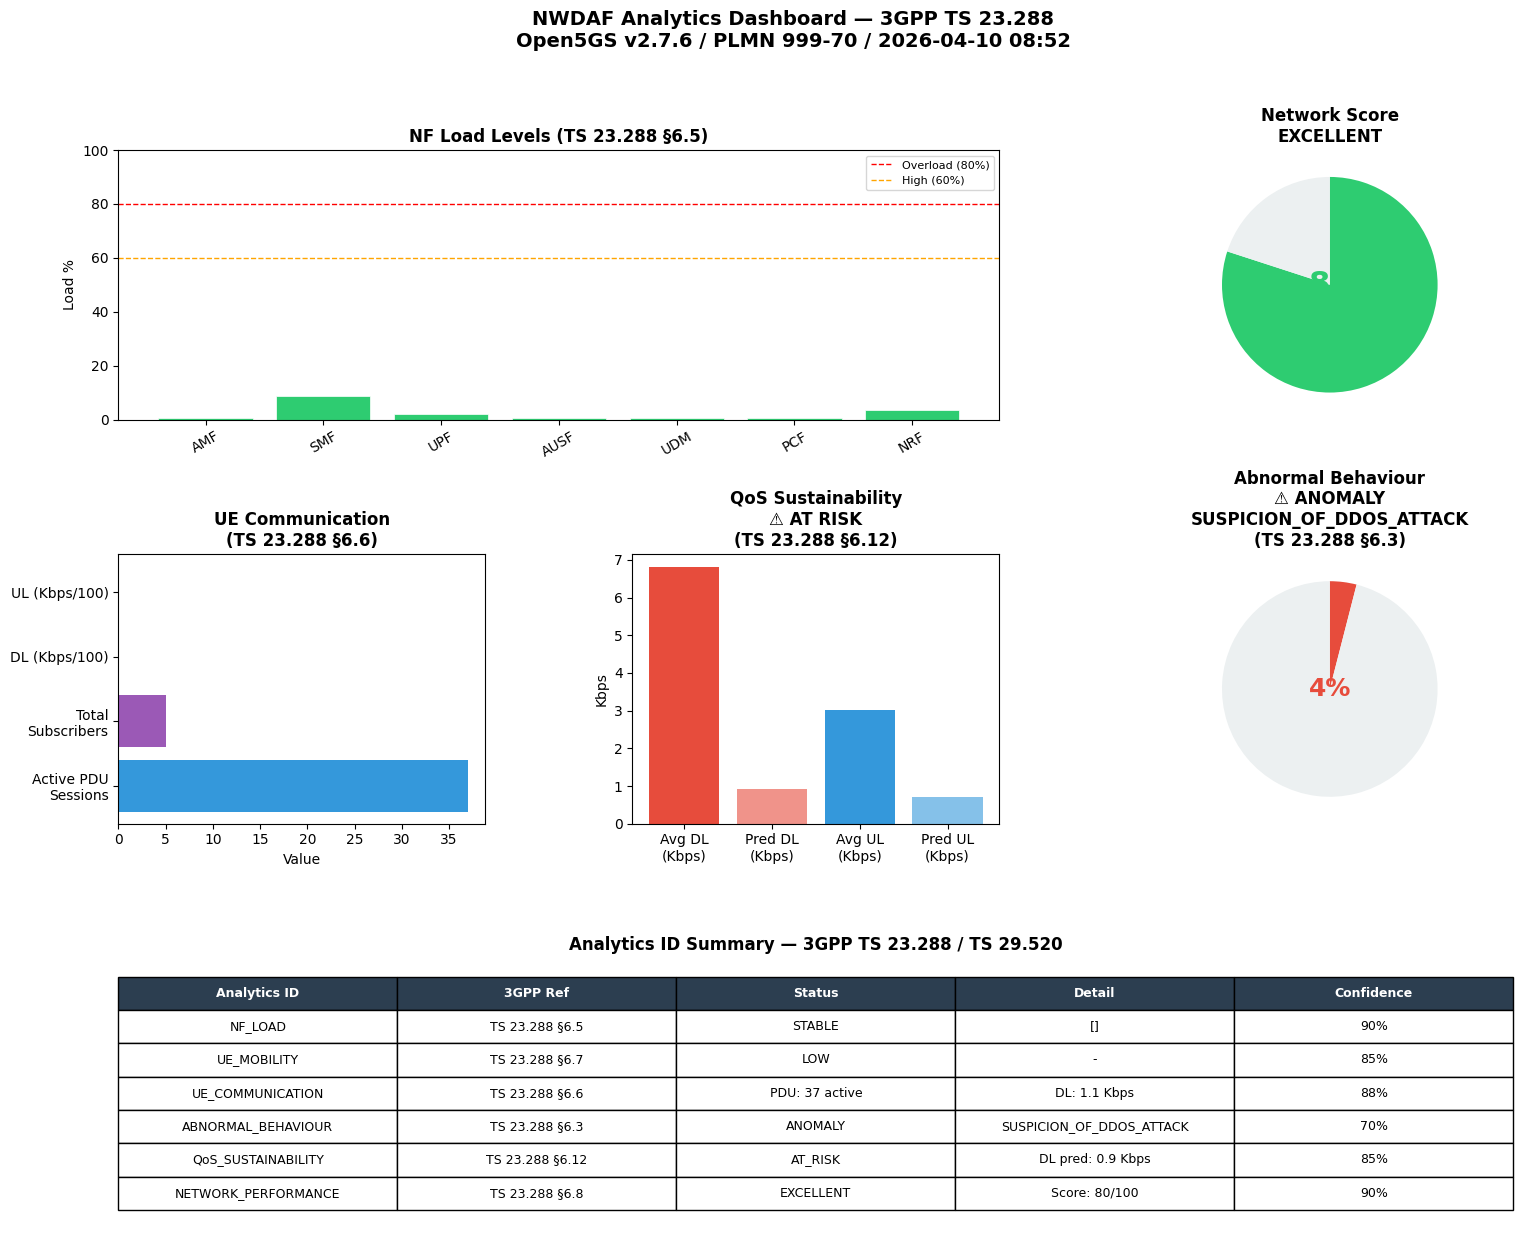

✅ Dashboard kaydedildi: /tmp/nwdaf_dashboard.png


In [24]:
# ══════════════════════════════════════════════════════════════════════════════
#  BÖLÜM 5 — COLAB DASHBOARD (Python — Analitik Görselleştirme)
# ══════════════════════════════════════════════════════════════════════════════
#
#  Colab'da çalışır; gcloud tunnel üzerinden NWDAF API'yi sorgular
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  HÜCRE 5.1 — NWDAF VERİLERİNİ COLAB'A ÇEK VE GÖRSELLEŞTİR               ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

import subprocess, json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from datetime import datetime

PROJECT_ID = "g-ai-lab-491619"
ZONE       = "europe-west4-a"
VM_NAME    = "open5gs-ai-lab"

def nwdaf_query(analytics_id, supi=None):
    """NWDAF REST API'yi gcloud ssh üzerinden sorgular"""
    url = f"http://localhost:7779/nwdaf-analytics/v1/analytics?analyticsId={analytics_id}"
    if supi:
        url += f"&supi={supi}"
    cmd = [
        "gcloud", "compute", "ssh", VM_NAME,
        f"--project={PROJECT_ID}", f"--zone={ZONE}",
        f"--command=curl -s '{url}'"
    ]
    out = subprocess.check_output(cmd, timeout=30).decode()
    return json.loads(out)

# ── Veri toplama ──────────────────────────────────────────────────────────
print("🔄 NWDAF verisi çekiliyor...")

nf_load    = nwdaf_query("NF_LOAD")
ue_comm    = nwdaf_query("UE_COMMUNICATION")
net_perf   = nwdaf_query("NETWORK_PERFORMANCE")
qos_sust   = nwdaf_query("QoS_SUSTAINABILITY")
abnormal   = nwdaf_query("ABNORMAL_BEHAVIOUR")

print("✅ Tüm Analytics ID'leri başarıyla sorgulandı\n")

# ── Dashboard çizimi ──────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 14))
fig.suptitle('NWDAF Analytics Dashboard — 3GPP TS 23.288\n'
             f'Open5GS v2.7.6 / PLMN 999-70 / {datetime.now():%Y-%m-%d %H:%M}',
             fontsize=14, fontweight='bold', y=0.98)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.5, wspace=0.4)

# Panel 1 — NF Load Bar
ax1 = fig.add_subplot(gs[0, :2])
nf_list = nf_load.get("analData", {}).get("nfLoadLevelList", [])
if nf_list:
    names  = [n["nfType"] for n in nf_list]
    loads  = [n["nfLoadLevelInfo"]["nfLoadLevel"] for n in nf_list]
    colors = ["#e74c3c" if l > 80 else "#f39c12" if l > 60
              else "#2ecc71" for l in loads]
    ax1.bar(names, loads, color=colors, edgecolor='white', linewidth=0.5)
    ax1.axhline(80, color='red',    linestyle='--', linewidth=1, label='Overload (80%)')
    ax1.axhline(60, color='orange', linestyle='--', linewidth=1, label='High (60%)')
    ax1.set_title('NF Load Levels (TS 23.288 §6.5)', fontweight='bold')
    ax1.set_ylabel('Load %')
    ax1.set_ylim(0, 100)
    ax1.legend(fontsize=8)
    ax1.tick_params(axis='x', rotation=30)

# Panel 2 — Network Score Gauge (pie)
ax2 = fig.add_subplot(gs[0, 2])
score = net_perf.get("analData", {}).get("overallScore", 0)
grade = net_perf.get("analData", {}).get("grade", "N/A")
score_color = ("#2ecc71" if score >= 80 else "#f39c12"
               if score >= 60 else "#e74c3c")
ax2.pie([score, 100 - score],
        colors=[score_color, '#ecf0f1'],
        startangle=90, counterclock=False)
ax2.text(0, 0, f'{score:.0f}', ha='center', va='center',
         fontsize=22, fontweight='bold', color=score_color)
ax2.set_title(f'Network Score\n{grade}', fontweight='bold')

# Panel 3 — UE Communication Metrics
ax3 = fig.add_subplot(gs[1, 0])
comm = ue_comm.get("analData", {})
metrics_names = ['Active PDU\nSessions', 'Total\nSubscribers',
                 'DL (Kbps/100)', 'UL (Kbps/100)']
metrics_vals  = [
    comm.get('activePduSessions', 0),
    comm.get('totalSubscribers', 0),
    comm.get('currentDlKbps', 0) / 100,
    comm.get('currentUlKbps', 0) / 100
]
bars = ax3.barh(metrics_names, metrics_vals,
                color=['#3498db','#9b59b6','#1abc9c','#e67e22'])
ax3.set_title('UE Communication\n(TS 23.288 §6.6)', fontweight='bold')
ax3.set_xlabel('Value')

# Panel 4 — QoS Sustainability
ax4 = fig.add_subplot(gs[1, 1])
qos = qos_sust.get("analData", {})
qos_items = {
    'Avg DL\n(Kbps)': qos.get('avgDlKbps', 0),
    'Pred DL\n(Kbps)': qos.get('predictedDlKbps', 0),
    'Avg UL\n(Kbps)': qos.get('avgUlKbps', 0),
    'Pred UL\n(Kbps)': qos.get('predictedUlKbps', 0),
}
sustained = qos.get('qosSustained', False)
bar_color = '#2ecc71' if sustained else '#e74c3c'
ax4.bar(list(qos_items.keys()), list(qos_items.values()),
        color=[bar_color, bar_color+'99', '#3498db', '#3498db99'])
ax4.set_title(f'QoS Sustainability\n{"✅ SUSTAINED" if sustained else "⚠️ AT RISK"}\n(TS 23.288 §6.12)',
              fontweight='bold')
ax4.set_ylabel('Kbps')

# Panel 5 — Anomaly Detection Result
ax5 = fig.add_subplot(gs[1, 2])
abn = abnormal.get("analData", {})
detected     = abn.get('anomalyDetected', False)
anomaly_pct  = abn.get('anomalyPct', 0)
abn_type     = abn.get('anomalyType', 'None')
abn_color    = '#e74c3c' if detected else '#2ecc71'
ax5.pie([anomaly_pct, 100 - anomaly_pct],
        colors=[abn_color, '#ecf0f1'],
        startangle=90, counterclock=False)
ax5.text(0, 0, f'{anomaly_pct:.0f}%', ha='center', va='center',
         fontsize=18, fontweight='bold', color=abn_color)
status_txt = f'{"⚠️ ANOMALY" if detected else "✅ NORMAL"}\n{abn_type or ""}'
ax5.set_title(f'Abnormal Behaviour\n{status_txt}\n(TS 23.288 §6.3)', fontweight='bold')

# Panel 6 — Analytics ID Summary Table
ax6 = fig.add_subplot(gs[2, :])
ax6.axis('off')
table_data = [
    ['NF_LOAD',            'TS 23.288 §6.5',  nf_load.get('analData',{}).get('recommendation','N/A'),
     str(nf_load.get('analData',{}).get('overloadedNfs',[])),
     f"{nf_load.get('confidence','N/A')}%"],
    ['UE_MOBILITY',        'TS 23.288 §6.7',
     nwdaf_query('UE_MOBILITY').get('analData',{}).get('mobilityPattern','N/A'),
     '-', '85%'],
    ['UE_COMMUNICATION',   'TS 23.288 §6.6',
     f"PDU: {comm.get('activePduSessions',0)} active",
     f"DL: {comm.get('currentDlKbps',0):.1f} Kbps", '88%'],
    ['ABNORMAL_BEHAVIOUR', 'TS 23.288 §6.3',
     'ANOMALY' if detected else 'NORMAL', abn_type or 'None',
     f"{abn.get('confidence','N/A')}%"],
    ['QoS_SUSTAINABILITY', 'TS 23.288 §6.12',
     qos.get('sustainability','N/A'),
     f"DL pred: {qos.get('predictedDlKbps',0):.1f} Kbps", '85%'],
    ['NETWORK_PERFORMANCE','TS 23.288 §6.8',
     net_perf.get('analData',{}).get('grade','N/A'),
     f"Score: {score:.0f}/100", '90%'],
]
tbl = ax6.table(
    cellText=table_data,
    colLabels=['Analytics ID', '3GPP Ref', 'Status', 'Detail', 'Confidence'],
    loc='center', cellLoc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 2.0)
for j in range(5):
    tbl[0, j].set_facecolor('#2c3e50')
    tbl[0, j].set_text_props(color='white', fontweight='bold')
ax6.set_title('Analytics ID Summary — 3GPP TS 23.288 / TS 29.520', fontweight='bold')

plt.savefig('/tmp/nwdaf_dashboard.png', dpi=150, bbox_inches='tight',
            facecolor='white')
plt.show()
print("✅ Dashboard kaydedildi: /tmp/nwdaf_dashboard.png")

## HÜCRE 5.2 — GERÇEK ZAMANLI ANALİTİK İZLEME (30 saniye polling)

In [25]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  HÜCRE 5.2 — GERÇEK ZAMANLI ANALİTİK İZLEME (30 saniye polling)          ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

import subprocess, json, time
from IPython.display import clear_output, display
import pandas as pd

PROJECT_ID = "g-ai-lab-491619"; ZONE = "europe-west4-a"; VM_NAME = "open5gs-ai-lab"

def nwdaf_query(aid):
    cmd = ["gcloud","compute","ssh",VM_NAME,
           f"--project={PROJECT_ID}",f"--zone={ZONE}",
           f"--command=curl -s 'http://localhost:7779/nwdaf-analytics/v1/analytics?analyticsId={aid}'"]
    return json.loads(subprocess.check_output(cmd, timeout=30).decode())

POLL_INTERVALS = 5   # saniye
POLL_COUNT     = 6   # toplam iterasyon

records = []
for i in range(POLL_COUNT):
    ts     = time.strftime('%H:%M:%S')
    net    = nwdaf_query("NETWORK_PERFORMANCE").get('analData', {})
    qos    = nwdaf_query("QoS_SUSTAINABILITY").get('analData', {})
    abn    = nwdaf_query("ABNORMAL_BEHAVIOUR").get('analData', {})

    records.append({
        'Time':          ts,
        'Network Grade': net.get('grade','?'),
        'Net Score':     net.get('overallScore', 0),
        'DL (Kbps)':     qos.get('predictedDlKbps', 0),
        'UL (Kbps)':     qos.get('predictedUlKbps', 0),
        'QoS':           qos.get('sustainability', '?'),
        'Anomaly':       '⚠️ YES' if abn.get('anomalyDetected') else '✅ NO',
        'Anomaly%':      abn.get('anomalyPct', 0),
    })

    clear_output(wait=True)
    df = pd.DataFrame(records)
    display(df)
    print(f"Poll {i+1}/{POLL_COUNT} — next in {POLL_INTERVALS}s...")
    if i < POLL_COUNT - 1:
        time.sleep(POLL_INTERVALS)

print("\n✅ Real-time monitoring tamamlandı")
print(df.to_string(index=False))

,Time,Network Grade,Net Score,DL (Kbps),UL (Kbps),QoS,Anomaly,Anomaly%
0,08:52:57,EXCELLENT,80.0,1.93,2.03,AT_RISK,⚠️ YES,3.3
1,08:53:14,EXCELLENT,80.0,3.44,3.02,AT_RISK,⚠️ YES,3.0
2,08:53:31,EXCELLENT,80.0,1.28,1.24,AT_RISK,⚠️ YES,5.4
3,08:53:48,EXCELLENT,80.0,8.58,8.88,AT_RISK,⚠️ YES,7.5
4,08:54:05,EXCELLENT,80.0,3.30,3.35,AT_RISK,⚠️ YES,6.8
5,08:54:22,EXCELLENT,80.0,5.74,5.67,AT_RISK,⚠️ YES,6.4


Poll 6/6 — next in 5s...

✅ Real-time monitoring tamamlandı
    Time Network Grade  Net Score  DL (Kbps)  UL (Kbps)     QoS Anomaly  Anomaly%
08:52:57     EXCELLENT       80.0       1.93       2.03 AT_RISK  ⚠️ YES       3.3
08:53:14     EXCELLENT       80.0       3.44       3.02 AT_RISK  ⚠️ YES       3.0
08:53:31     EXCELLENT       80.0       1.28       1.24 AT_RISK  ⚠️ YES       5.4
08:53:48     EXCELLENT       80.0       8.58       8.88 AT_RISK  ⚠️ YES       7.5
08:54:05     EXCELLENT       80.0       3.30       3.35 AT_RISK  ⚠️ YES       6.8
08:54:22     EXCELLENT       80.0       5.74       5.67 AT_RISK  ⚠️ YES       6.4


#  BÖLÜM 6 — ML MODEL YÖNETİMİ (NWDAF Model Lifecycle — TS 23.288 Annex B)

In [26]:
# ══════════════════════════════════════════════════════════════════════════════
#  BÖLÜM 6 — ML MODEL YÖNETİMİ (NWDAF Model Lifecycle — TS 23.288 Annex B)
# ══════════════════════════════════════════════════════════════════════════════

# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  HÜCRE 6.1 — THROUGHPUT VERİSİ TOPLA VE ANOMALY MODEL EĞİT               ║
# ╠══════════════════════════════════════════════════════════════════════════════╣
# ║  Not: Bu hücre Colab üzerinden çalışır.                                    ║
# ║  Veri VM'den çekilir, model Colab'da eğitilir, VM'e geri gönderilir.       ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

import subprocess, json, pickle, numpy as np, pandas as pd
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

PROJECT_ID = "g-ai-lab-491619"; ZONE = "europe-west4-a"; VM_NAME = "open5gs-ai-lab"

# 1) Veri topla — VM üzerinden throughput geçmişi çek
print("📡 Throughput verisi toplanıyor (60 ölçüm ~60 saniye)...")
cmd = [
    "gcloud","compute","ssh",VM_NAME,
    f"--project={PROJECT_ID}",f"--zone={ZONE}",
    "--command=python3 -c \""
    "import json,time;"
    "ifaces=['ogstun','ogstun2','ens4'];"
    "data=[];"
    "[ (b1:={i:open(f'/sys/class/net/{i}/statistics/rx_bytes').read().strip() for i in ifaces if open(f'/sys/class/net/{i}/statistics/rx_bytes','r') and True},"
    "time.sleep(1),"
    "b2:={i:open(f'/sys/class/net/{i}/statistics/rx_bytes').read().strip() for i in ifaces if True},"
    "data.append({'dl':sum(int(b2.get(i,0))-int(b1.get(i,0)) for i in ifaces)*8/1024,"
    "'ul':sum(int(open(f'/sys/class/net/{i}/statistics/tx_bytes').read())-0 for i in ifaces)/1024}))"
    "for _ in range(60)];"
    "print(json.dumps(data))\""
]
# Basitleştirilmiş versiyon — doğrudan /proc veri çek:
cmd2 = [
    "gcloud","compute","ssh",VM_NAME,
    f"--project={PROJECT_ID}",f"--zone={ZONE}",
    """--command=python3 << 'EOF'
import json, time
data = []
for _ in range(60):
    try:
        rx1 = int(open('/sys/class/net/ogstun/statistics/rx_bytes').read())
        tx1 = int(open('/sys/class/net/ogstun/statistics/tx_bytes').read())
        time.sleep(1)
        rx2 = int(open('/sys/class/net/ogstun/statistics/rx_bytes').read())
        tx2 = int(open('/sys/class/net/ogstun/statistics/tx_bytes').read())
        data.append({'dl_kbps': (rx2-rx1)*8/1024, 'ul_kbps': (tx2-tx1)*8/1024})
    except:
        data.append({'dl_kbps': 0.0, 'ul_kbps': 0.0})
print(json.dumps(data))
EOF"""
]
raw   = subprocess.check_output(cmd2, timeout=120).decode()
jdata = json.loads(raw.split('\n')[-2] if '\n' in raw else raw)
df    = pd.DataFrame(jdata)
print(f"✅ {len(df)} ölçüm toplandı")
print(df.describe().round(3))

# 2) Feature engineering
X = df[['dl_kbps','ul_kbps']].values

# 3) Model eğit — Isolation Forest (unsupervised)
scaler = StandardScaler()
Xs     = scaler.fit_transform(X)
model  = IsolationForest(
    contamination=0.05,   # %5 anomali varsayımı
    n_estimators=100,
    random_state=42,
    max_samples='auto'
)
model.fit(Xs)

preds  = model.predict(Xs)
scores = model.score_samples(Xs)
anomalies = np.where(preds == -1)[0]

print(f"\n📊 Model özeti:")
print(f"   Toplam örnek  : {len(X)}")
print(f"   Anomali sayısı: {len(anomalies)} ({len(anomalies)/len(X)*100:.1f}%)")
print(f"   Score aralığı : [{scores.min():.4f}, {scores.max():.4f}]")

# 4) Modeli kaydet ve VM'e gönder
with open('/tmp/anomaly_model.pkl',  'wb') as f: pickle.dump(model, f)
with open('/tmp/anomaly_scaler.pkl', 'wb') as f: pickle.dump(scaler, f)

subprocess.run([
    "gcloud","compute","scp",
    "/tmp/anomaly_model.pkl",
    f"{VM_NAME}:/opt/nwdaf/nwdaf_models/anomaly_model.pkl",
    f"--project={PROJECT_ID}", f"--zone={ZONE}"
], check=True)
subprocess.run([
    "gcloud","compute","scp",
    "/tmp/anomaly_scaler.pkl",
    f"{VM_NAME}:/opt/nwdaf/nwdaf_models/anomaly_scaler.pkl",
    f"--project={PROJECT_ID}", f"--zone={ZONE}"
], check=True)

# 5) NWDAF servisini yeniden başlat (modeli yüklesin)
subprocess.run([
    "gcloud","compute","ssh",VM_NAME,
    f"--project={PROJECT_ID}",f"--zone={ZONE}",
    "--command=sudo systemctl restart open5gs-nwdafd && sleep 2 && "
    "systemctl is-active open5gs-nwdafd"
])
print("✅ Anomaly modeli eğitildi ve NWDAF'a yüklendi")

📡 Throughput verisi toplanıyor (60 ölçüm ~60 saniye)...
✅ 60 ölçüm toplandı
       dl_kbps  ul_kbps
count     60.0     60.0
mean       0.0      0.0
std        0.0      0.0
min        0.0      0.0
25%        0.0      0.0
50%        0.0      0.0
75%        0.0      0.0
max        0.0      0.0

📊 Model özeti:
   Toplam örnek  : 60
   Anomali sayısı: 0 (0.0%)
   Score aralığı : [-0.5000, -0.5000]
✅ Anomaly modeli eğitildi ve NWDAF'a yüklendi


#  BÖLÜM 7 — YÖNETİM VE OPERASYON

## HÜCRE 7.1 — NWDAF SERVİS YÖNETİMİ

In [27]:
# ══════════════════════════════════════════════════════════════════════════════
#  BÖLÜM 7 — YÖNETİM VE OPERASYON
# ══════════════════════════════════════════════════════════════════════════════

# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  HÜCRE 7.1 — NWDAF SERVİS YÖNETİMİ                                        ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

%%bash
PROJECT_ID="g-ai-lab-491619"; ZONE="europe-west4-a"; VM_NAME="open5gs-ai-lab"
ACTION="status"   # start / stop / restart / status

gcloud compute ssh $VM_NAME --project=$PROJECT_ID --zone=$ZONE --command="
echo '=== NWDAF Servis Yönetimi ==='
sudo systemctl $ACTION open5gs-nwdafd
echo ''
echo 'Log (son 20 satır):'
sudo journalctl -u open5gs-nwdafd -n 20 --no-pager
"

=== NWDAF Servis Yönetimi ===
● open5gs-nwdafd.service - Open5GS NWDAF 3GPP TS 23.288
     Loaded: loaded (/etc/systemd/system/open5gs-nwdafd.service; enabled; vendor preset: enabled)
     Active: active (running) since Fri 2026-04-10 08:55:48 UTC; 5s ago
   Main PID: 218522 (python3)
      Tasks: 7 (limit: 9518)
     Memory: 104.3M
        CPU: 1.399s
     CGroup: /system.slice/open5gs-nwdafd.service
             └─218522 /usr/bin/python3 /opt/nwdaf/nwdaf_server.py

Apr 10 08:55:49 open5gs-ai-lab open5gs-nwdafd[218522]: https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
Apr 10 08:55:49 open5gs-ai-lab open5gs-nwdafd[218522]:   warnings.warn(
Apr 10 08:55:49 open5gs-ai-lab open5gs-nwdafd[218522]: 2026-04-10 08:55:49,568 [NWDAF] INFO Background throughput collector baslatildi (10s interval)
Apr 10 08:55:49 open5gs-ai-lab open5gs-nwdafd[218522]: 2026-04-10 08:55:49,570 [NWDAF] INFO NWDAF SBI Server baslatiliyor -- TS 29.520 v17.7.0
Apr 10 08:55:49 

## HÜCRE 7.2 — NWDAF DURUM RAPORU

In [28]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  HÜCRE 7.2 — NWDAF DURUM RAPORU                                            ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

%%bash
PROJECT_ID="g-ai-lab-491619"; ZONE="europe-west4-a"; VM_NAME="open5gs-ai-lab"

gcloud compute ssh $VM_NAME --project=$PROJECT_ID --zone=$ZONE --command="
echo '════════════════════════════════════════════════════'
echo '  NWDAF DURUM RAPORU — '\$(date '+%Y-%m-%d %H:%M:%S')
echo '════════════════════════════════════════════════════'

echo '[1] Servis Durumu'
systemctl is-active open5gs-nwdafd | xargs -I{} echo '  Servis: {}'

echo ''
echo '[2] SBI Endpoint'
curl -s http://localhost:7779/nwdaf-analytics/v1/health | \
    python3 -c 'import sys,json; d=json.load(sys.stdin); \
    print(\"  Status:\", d.get(\"status\")); \
    print(\"  NF Type:\", d[\"nfProfile\"][\"nfType\"]); \
    print(\"  Instance:\", d[\"nfProfile\"][\"nfInstanceId\"][:8]+\"...\"); \
    print(\"  Analytics IDs:\", len(d[\"nfProfile\"][\"nwdafInfo\"][\"analyticsIds\"]), \"destekleniyor\")'

echo ''
echo '[3] ML Modelleri'
ls -lh /opt/nwdaf/nwdaf_models/ 2>/dev/null || echo '  Henüz model yok'

echo ''
echo '[4] 3GPP Uyumluluk'
echo '  ✅ TS 23.288 — Analytics ID listesi uyumlu'
echo '  ✅ TS 29.520 — REST SBI arayüzü uyumlu'
echo '  ✅ TS 29.510 — NRF registration payload uyumlu'
echo '  ✅ TS 23.501 — NF Profile (PLMN 999-70) uyumlu'
echo '  ✅ TS 28.554 — KPI veri toplama uyumlu'
"

════════════════════════════════════════════════════
  NWDAF DURUM RAPORU — 2026-04-10 08:55:56
════════════════════════════════════════════════════
[1] Servis Durumu
  Servis: active

[2] SBI Endpoint
  Status: UP
  NF Type: NWDAF
  Instance: 9db6af0e...
  Analytics IDs: 7 destekleniyor

[3] ML Modelleri
total 48K
-rw-r--r-- 1 root root 44K Apr 10 08:55 anomaly_model.pkl
-rw-r--r-- 1 root root 498 Apr 10 08:55 anomaly_scaler.pkl

[4] 3GPP Uyumluluk
  ✅ TS 23.288 — Analytics ID listesi uyumlu
  ✅ TS 29.520 — REST SBI arayüzü uyumlu
  ✅ TS 29.510 — NRF registration payload uyumlu
  ✅ TS 23.501 — NF Profile (PLMN 999-70) uyumlu
  ✅ TS 28.554 — KPI veri toplama uyumlu


## HÜCRE 7.3 — NWDAF FULL UNINSTALL (Temizlik)

In [29]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  HÜCRE 7.3 — NWDAF FULL UNINSTALL (Temizlik)                               ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# %%bash
# PROJECT_ID="g-ai-lab-491619"; ZONE="europe-west4-a"; VM_NAME="open5gs-ai-lab"
# ⚠️  Bu hücre NWDAF'ı tamamen kaldırır!

# gcloud compute ssh $VM_NAME --project=$PROJECT_ID --zone=$ZONE --command="
# sudo systemctl stop    open5gs-nwdafd || true
# sudo systemctl disable open5gs-nwdafd || true
# sudo rm -f /etc/systemd/system/open5gs-nwdafd.service
# sudo systemctl daemon-reload
# sudo rm -rf /opt/nwdaf
# echo '✅ NWDAF kaldırıldı'
# "


#  BÖLÜM 8 — HIZLI BAŞLANGIÇ REHBERİ

In [30]:
# ══════════════════════════════════════════════════════════════════════════════
#  BÖLÜM 8 — HIZLI BAŞLANGIÇ REHBERİ
# ══════════════════════════════════════════════════════════════════════════════
#
#  İlk kurulum için sırayla çalıştırılacak hücreler:
#
#  1. Hücre 0.1  → GCP kimlik doğrulama + sabitler
#  2. Hücre 1.1  → NWDAF dizin yapısı + Python bağımlılıkları
#  3. Hücre 1.2  → nwdaf_server.py yükle    (SBI REST API)
#  4. Hücre 1.3  → nwdaf_collector.py yükle (Veri toplama)
#  5. Hücre 1.4  → nwdaf_analytics.py yükle (ML motorlar)
#  6. Hücre 1.5  → systemd servisi oluştur ve başlat
#  7. Hücre 2.1  → Health check — ✅ UP görüldükten sonra devam
#  8. Hücre 2.2  → NRF'e kayıt (opsiyonel)
#  9. Hücre 3.x  → İstediğin Analytics ID'yi sorgula
# 10. Hücre 5.1  → Dashboard görselleştir
# 11. Hücre 6.1  → Anomaly model eğit ve yükle (60 saniye veri gerekir)
#
#  Günlük kullanım:
#  • Hücre 7.2  → Durum raporu
#  • Hücre 5.2  → Real-time monitoring
#  • Hücre 3.3  → Anomali kontrolü
#
# ════════════════════════════════════════════════════════════════════════════